# Initial setup

## Some Jupyter notebook setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


## WatChMaL imports

In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Preparing data

## Get true particle data from h5 file

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:


idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz"

test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']



In [9]:


data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")


In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:

data_new_geo = get_values(h5_file_new_geo, test_idxs_new_geo)


# Get fitQun data from files

In [12]:
def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
    N = len(all_event_ids)
    cut_start_idxs: list[int] = [0]
    CUTOFF = 500
    for i in range(N - 1):
        if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
            cut_start_idxs.append(i+ 1)
    cut_start_idxs.append(len(all_event_ids)-1)
    return cut_start_idxs

def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
    missing_ids_fq = []
    missing_inds_fq = []
    missing_ids_h5 = []    
    missing_inds_h5 = []
    n_cuts = len(fq_cuts)
    assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
    for i in range(1, n_cuts):
        fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
        h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

        fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
        h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

        assert fq_ids[0] < 100
        assert fq_ids[-1] > 990

        missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
        if len(missing_both) > 0:
            print(missing_both)

        missing_fq = np.setdiff1d(fq_ids, h5_ids)
        inds_fq = np.searchsorted(fq_ids, missing_fq)

        missing_ids_fq.append(missing_fq.tolist())
        missing_inds_fq.append(fq_start_idx + inds_fq)


        missing_h5 = np.setdiff1d(h5_ids, fq_ids)
        inds_h5 = np.searchsorted(h5_ids, missing_h5)

        missing_ids_h5.append(missing_h5.tolist())
        missing_inds_h5.append(h5_start_idx + inds_h5)
    
    return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
fq = FiTQunOutput(fitqun_files_full)

In [14]:
#Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
fq_event_ids = fq.chain['nevt'] #.compute()
fq_event_ids =  ak.to_numpy(fq_event_ids) -1
h5_event_ids = data_new_geo['event_ids']

fq_cuts = get_cut_start_idxs(fq_event_ids)
h5_cuts = get_cut_start_idxs(h5_event_ids)
missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
print('The number of extra fq indices is:', len(missing_indices_fq))
print('The number of extra h5 indices is:', len(missing_indices_h5))

The difference between fitqun and h5 event ids is: 61041
The number of extra fq indices is: 61043
The number of extra h5 indices is: 2


In [15]:
fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
fq_electron_momentum = fq.electron_momentum 
fq_electron_momentum = ak.to_numpy(fq_electron_momentum)
fq_electron_momentum = np.delete(fq_electron_momentum, missing_indices_fq)

fq_muon_momentum = fq.muon_momentum 
fq_muon_momentum = ak.to_numpy(fq_muon_momentum)
fq_muon_momentum = np.delete(fq_muon_momentum, missing_indices_fq)

In [17]:
fq_electron_position = fq.electron_position
fq_electron_position = ak.to_numpy(fq_electron_position)
fq_electron_position = np.delete(fq_electron_position, missing_indices_fq)

fq_muon_position = fq.muon_position 
fq_muon_position= ak.to_numpy(fq_muon_position)
fq_muon_position = np.delete(fq_muon_position, missing_indices_fq)

In [18]:
fq_electron_direction = fq.electron_direction
fq_electron_direction = ak.to_numpy(fq_electron_direction)
fq_electron_direction = np.delete(fq_electron_direction, missing_indices_fq)

fq_muon_direction = fq.muon_direction 
fq_muon_direction = ak.to_numpy(fq_muon_direction)
fq_muon_direction = np.delete(fq_muon_direction, missing_indices_fq)

In [19]:
h5_electron_flag = fq.electron_flag
h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
h5_muon_flag = fq.muon_flag#.compute()
h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

fc_cut = data_new_geo['fc'][h5_keep_idx]
mu_cut = data_new_geo['labels'][h5_keep_idx]==2
el_cut = data_new_geo['labels'][h5_keep_idx]==1

reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [20]:
# import inspect
# print(inspect.signature(FitQun1ParticleFit))


In [21]:
# mu_mu = np.delete(fq.muon_nll.compute(), missing_indices)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll.compute(), missing_indices)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll.compute(), missing_indices)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll.compute(), missing_indices)[fc_cut & el_cut & reco_cut]

mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
fq_mu_nll = mu_mu - el_mu
fq_el_nll = mu_el - el_el

In [22]:
# min = -750
# max = 1000
# plt.hist(fq_mu_nll, bins=100, histtype='step', label='Muons', range=(min, max))
# plt.hist(fq_el_nll, bins=100, histtype='step', label='Electrons', range=(min, max))
# plt.xlabel("Nll_e - Nll_μ", size=16)
# plt.ylabel("# Entries", size=16)
# plt.legend()
# #plt.yscale('log')
# plt.show()

In [23]:
# #Cut out the missing indices from the fitqun data
# from matplotlib.patches import Rectangle

# # true_momenta = data_fixed['momentum']
# # nhits = data_fixed['nhits']

# true_momenta = data_new_geo['momentum'][h5_keep_idx]
# nhits = data_new_geo['nhits'][h5_keep_idx]

# #reset matplotlib settings
# # matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# fig, ax = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)

# all_mu_cuts = fc_cut & mu_cut & reco_cut & (nhits > 25)
# all_el_cuts = fc_cut & el_cut & reco_cut & (nhits > 25)

# h1 = ax[0, 0].hist2d(true_momenta[mu_cut], fq_muon_momentum[mu_cut], bins=100, range=[[0,1000],[0,1000]])
# h2 = ax[0, 1].hist2d(true_momenta[all_mu_cuts], fq_muon_momentum[all_mu_cuts], bins=100, range=[[0,1000],[0,1000]])
# h3 = ax[1, 0].hist2d(true_momenta[el_cut], fq_electron_momentum[el_cut], bins=100, range=[[0,1000],[0,1000]])
# h4 = ax[1, 1].hist2d(true_momenta[all_el_cuts], fq_electron_momentum[all_el_cuts], bins=100, range=[[0,1000],[0,1000]])

# ax[0,0].set_title("All muons")
# ax[0,1].set_title("Cut muons")
# ax[1,0].set_title("All electrons")
# ax[1,1].set_title("Cut electrons")

# ax[0,0].set_xticks([])
# ax[0,1].set_xticks([])

# for ai in ax.flat:
#     im = ai.imshow([[min, max], [min, max]], cmap='viridis', vmin=0, vmax= np.max([h1[0].max(), h2[0].max(), h3[0].max(), h4[0].max()]))

# cbar = fig.colorbar(im, ax=ax.ravel().tolist())
# fs = 15
# cbar.set_label('# Entries', size=fs)
# fig.suptitle('FitQun reco vs true Momentum (with FC, reco and nhits>25 cuts)', size=fs)
# fig.supxlabel('True Momentum [MeV/c]', size=fs)
# fig.supylabel('FitQun Momentum [MeV/c]', size=fs)
# plt.show()

# plt.figure(figsize=(10,8))
# plt.hist(true_momenta[all_el_cuts], bins=50, histtype='step', range=(0,1000), label='True Momentum' )
# plt.hist(fq_electron_momentum[el_cut & fc_cut], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut only)')
# plt.hist(fq_electron_momentum[el_cut & fc_cut & reco_cut], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut and reco cut)')
# plt.hist(fq_electron_momentum[all_el_cuts], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut, reco cut and nhits>25)')

# plt.legend()
# plt.xlabel('True Electron Momentum [MeV/c]')
# plt.ylabel('# Entries')
# plt.show()

# plt.figure(figsize=(10,8))
# plt.hist(true_momenta[all_mu_cuts], bins=50, histtype='step', range=(0,1000), label='True Momentum' )
# plt.hist(fq_muon_momentum[mu_cut & fc_cut], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut only)')
# plt.hist(fq_muon_momentum[mu_cut & fc_cut & reco_cut], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut and reco cut)')
# plt.hist(fq_muon_momentum[all_mu_cuts], bins=50, histtype='step', range=(0,1000), label='fiTQun mom (FC cut, reco cut and nhits>25)')
# plt.legend()
# plt.xlabel('True Muon Momentum [MeV/c]')
# plt.ylabel('# Entries')
# plt.show()

# Plotting ResNet performance

## Set up plotting style

In [24]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

## Make some cuts to select the events of interest

In [25]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

# cuts_fixed_geo = apply_cuts(data_fixed)
cuts_new_geo = apply_cuts(data_new_geo)
# cuts_old_geo = apply_cuts(data_old_geo)

# h5_electron_flag = fq.electron_flag.compute()
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices)

# h5_muon_flag = fq.muon_flag.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices)


# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

# cuts_new_geo = cuts_new_geo #& reco_cut

In [26]:
# e_idxs_fixed_geo = data_fixed['labels']==1
# mu_idxs_fixed_geo = data_fixed['labels']==2

e_idxs_new_geo = data_new_geo['labels']==1
mu_idxs_new_geo = data_new_geo['labels']==2

# e_idxs_old_geo = data_old_geo['labels']==1
# mu_idxs_old_geo = data_old_geo['labels']==2

In [27]:
# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices)[data_new_geo['labels']==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices)[data_new_geo['labels']==1]

In [28]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [29]:
# fixed geo electrons & muons
# e_labels_f, e_mom_f, e_pos_f, e_dir_f, e_ang_f, e_dwall_f, e_towall_f, e_cuts_f, e_idxs_f = get_particle_quantities(data_fixed, 1, cuts_fixed_geo)
# mu_labels_f, mu_mom_f, mu_pos_f, mu_dir_f, mu_ang_f, mu_dwall_f, mu_towall_f, mu_cuts_f, mu_idxs_f = get_particle_quantities(data_fixed, 2, cuts_fixed_geo)

# # New geo electrons & muons
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)


# h5 keep idx apply here?


# Old geo electrons & muons
# e_labels_o, e_mom_o, e_pos_o, e_dir_o, e_ang_o, e_dwall_o, e_towall_o, e_cuts_o, e_idxs_o = get_particle_quantities(data_old_geo, 1, cuts_old_geo)
# mu_labels_o, mu_mom_o, mu_pos_o, mu_dir_o, mu_ang_o, mu_dwall_o, mu_towall_o, mu_cuts_o, mu_idxs_o = get_particle_quantities(data_old_geo, 2, cuts_old_geo)

In [30]:
resnet_args = {'linestyle':"-"}

# # electron_args_fixed_geo = {'indices':test_idxs_fixed[e_idxs_fixed_geo], 'selection':e_cuts_f}
# # muon_args_fixed_geo = {'indices':test_idxs_fixed[mu_idxs_fixed_geo],'selection':mu_cuts_f}
# # muon_args_fixed_geo_g800 = {'indices':test_idxs_fixed[mu_idxs_fixed_geo],'selection':mu_cuts_f & (mu_mom_f > 800)}

electron_args_new_geo = {'indices':test_idxs_new_geo[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts}

# electron_args_old_geo = {'indices':test_idxs_old_geo[e_idxs_old_geo], 'selection':e_cuts_o}
# muon_args_old_geo = {'indices':test_idxs_old_geo[mu_idxs_old_geo],'selection':mu_cuts_o}

# fqplotargs={'linestyle':"-", 'color':"#ffa500"} #0 Fitqun (orange)
# fqplotargs2={'linestyle':"-", 'color':"#6b506b"}
# fqplotargs3={'linestyle':"-"} # 0 FitQun Basic Cuts (Red)
# fqplotargs4={'linestyle':"-"} #1 FitQun All Cuts (Red)

## Bin events in various quantities

In [31]:
# # Electron binning
# electron_mom_binning = [get_binning(data_new_geo['momentum'][e_idxs_new_geo], 20, 0, 1000),
#                         get_binning(data_new_geo['momentum'][e_idxs_new_geo], 20, 0, 1000),
#                         get_binning(data_old_geo['momentum'][e_idxs_old_geo], 20, 0, 1000),
#                         get_binning(data_old_geo['momentum'][e_idxs_old_geo], 20, 0, 1000),
#                         get_binning(data_new_geo['momentum'][e_idxs_new_geo], 20, 0, 1000),]

# electron_cos_zenith_binning = [get_binning(np.cos(data_new_geo['angles'][e_idxs_new_geo,0]), 20, -1, 1),
#                                get_binning(np.cos(data_new_geo['angles'][e_idxs_new_geo,0]), 20, -1, 1),
#                                get_binning(np.cos(data_old_geo['angles'][e_idxs_old_geo,0]), 20, -1, 1),
#                                get_binning(np.cos(data_old_geo['angles'][e_idxs_old_geo,0]), 20, -1, 1),
#                                get_binning(np.cos(data_new_geo['angles'][e_idxs_new_geo,0]), 20, -1, 1),]

# electron_azimuth_binning = [get_binning(data_new_geo['angles'][e_idxs_new_geo,1]*180/np.pi, 20, -180, 180),
#                             get_binning(data_new_geo['angles'][e_idxs_new_geo,1]*180/np.pi, 20, -180, 180),
#                             get_binning(data_old_geo['angles'][e_idxs_old_geo,1]*180/np.pi, 20, -180, 180),
#                             get_binning(data_old_geo['angles'][e_idxs_old_geo,1]*180/np.pi, 20, -180, 180),
#                             get_binning(data_new_geo['angles'][e_idxs_new_geo,1]*180/np.pi, 20, -180, 180),]

# electron_dwall_binning = [get_binning(data_new_geo['dwall'][e_idxs_new_geo], 22, 50, 300),
#                           get_binning(data_new_geo['dwall'][e_idxs_new_geo], 22, 50, 300),
#                           get_binning(data_old_geo['dwall'][e_idxs_old_geo], 22, 50, 300),
#                           get_binning(data_old_geo['dwall'][e_idxs_old_geo], 22, 50, 300),
#                           get_binning(data_new_geo['dwall'][e_idxs_new_geo], 22, 50, 300),]

# electron_towall_binning = [get_binning(data_new_geo['towall'][e_idxs_new_geo], 30, 50, 800),
#                            get_binning(data_new_geo['towall'][e_idxs_new_geo], 30, 50, 800),
#                            get_binning(data_old_geo['towall'][e_idxs_old_geo], 30, 50, 800),
#                            get_binning(data_old_geo['towall'][e_idxs_old_geo], 30, 50, 800),
#                            get_binning(data_new_geo['towall'][e_idxs_new_geo], 30, 50, 800),]

# # Muon binning
# muon_mom_binning = [get_binning(data_new_geo['momentum'][mu_idxs_new_geo], 20, 0, 1000),
#                     get_binning(data_new_geo['momentum'][mu_idxs_new_geo], 20, 0, 1000),
# #                     get_binning(data_old_geo['momentum'][mu_idxs_old_geo], 20, 0, 1000),
# #                     get_binning(data_old_geo['momentum'][mu_idxs_old_geo], 20, 0, 1000),
#                     get_binning(data_new_geo['momentum'][mu_idxs_new_geo], 20, 0, 1000),]

# muon_cos_zenith_binning = [get_binning(np.cos(data_new_geo['angles'][mu_idxs_new_geo,0]), 20, -1, 1),
#                            get_binning(np.cos(data_new_geo['angles'][mu_idxs_new_geo,0]), 20, -1, 1),
# #                            get_binning(np.cos(data_old_geo['angles'][mu_idxs_old_geo,0]), 20, -1, 1),
# #                            get_binning(np.cos(data_old_geo['angles'][mu_idxs_old_geo,0]), 20, -1, 1),
#                            get_binning(np.cos(data_new_geo['angles'][mu_idxs_new_geo,0]), 20, -1, 1)]

# muon_azimuth_binning = [get_binning(data_new_geo['angles'][mu_idxs_new_geo,1]*180/np.pi, 20, -180, 180),
#                         get_binning(data_new_geo['angles'][mu_idxs_new_geo,1]*180/np.pi, 20, -180, 180),
# #                         get_binning(data_old_geo['angles'][mu_idxs_old_geo,1]*180/np.pi, 20, -180, 180),
# #                         get_binning(data_old_geo['angles'][mu_idxs_old_geo,1]*180/np.pi, 20, -180, 180), 
#                         get_binning(data_new_geo['angles'][mu_idxs_new_geo,1]*180/np.pi, 20, -180, 180),]

# muon_dwall_binning = [get_binning(data_new_geo['dwall'][mu_idxs_new_geo], 22, 50, 300),
#                       get_binning(data_new_geo['dwall'][mu_idxs_new_geo], 22, 50, 300),
# #                       get_binning(data_old_geo['dwall'][mu_idxs_old_geo], 22, 50, 300),
# #                       get_binning(data_old_geo['dwall'][mu_idxs_old_geo], 22, 50, 300),
#                       get_binning(data_new_geo['dwall'][mu_idxs_new_geo], 22, 50, 300),]

# muon_towall_binning = [get_binning(data_new_geo['towall'][mu_idxs_new_geo], 30, 50, 800),
#                        get_binning(data_new_geo['towall'][mu_idxs_new_geo], 30, 50, 800),
# #                        get_binning(data_old_geo['towall'][mu_idxs_old_geo], 30, 50, 800),
# #                        get_binning(data_old_geo['towall'][mu_idxs_old_geo], 30, 50, 800),
#                        get_binning(data_new_geo['towall'][mu_idxs_new_geo], 30, 50, 800),]



In [32]:
# muon_mom_binning = get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 20, 0, 1200)
# muon_cos_zenith_binning = get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 20, -1, 1)
# muon_azimuth_binning = get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 20, -180, 180)
# muon_dwall_binning = get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 30, 50, 400)
# muon_towall_binning = get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 50, 400)

In [33]:
# # Muon binning

# muon_mom_binning = [get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 10, 100, 1000),
#                     get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 10, 100, 1000),
#                     get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 10, 100, 1000),
#                     get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 10, 100, 1000),
#                     get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 10, 100, 1000),
#                     get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 20, 0, 1000),
#                     # get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 20, 0, 1000),
#                     # get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 5, 800, 1000),
#                     # get_binning(data_fixed['momentum'][mu_idxs_fixed_geo], 5, 800, 1000),
#                   #   get_binning(data_new_geo['momentum'][mu_idxs_new_geo], 20, 0, 1000)
#                   ]
                    

# muon_cos_zenith_binning = [get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 10, -1, 1),
#                            get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 10, -1, 1),
#                            get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 10, -1, 1),
#                            get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 10, -1, 1),
#                            get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 10, -1, 1),
#                            get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 20, -1, 1),
#                         #    get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 20, -1, 1),
#                         #    get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 20, -1, 1),
#                         #    get_binning(np.cos(data_fixed['angles'][mu_idxs_fixed_geo,0]), 20, -1, 1),
#                            # get_binning(np.cos(data_new_geo['angles'][mu_idxs_new_geo,0]), 20, -1, 1)
#                            ]

# muon_azimuth_binning = [get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 10, -180, 180),
#                         get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 10, -180, 180),
#                         get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 10, -180, 180),
#                         get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 10, -180, 180),
#                         get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 10, -180, 180),
#                         get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 20, -180, 180),
#                         # get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 20, -180, 180),
#                         # get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 20, -180, 180),
#                         # get_binning(data_fixed['angles'][mu_idxs_fixed_geo,1]*180/np.pi, 20, -180, 180),
#                         # get_binning(data_new_geo['angles'][mu_idxs_new_geo,1]*180/np.pi, 20, -180, 180)
#                         ]
                        
# muon_dwall_binning = [get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 10, 0, 150),
#                       get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 10, 0, 150),
#                       get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 10, 0, 150),
#                       get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 10, 0, 150),
#                       get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 10, 0, 150),
#                       get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 30, 100, 400),
#                     #   get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 30, 100, 400),
#                     #   get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 30, 100, 400),
#                     #   get_binning(data_fixed['dwall'][mu_idxs_fixed_geo], 30, 100, 400),
#                      #  get_binning(data_new_geo['dwall'][mu_idxs_new_geo], 30, 100, 400)
#                      ]
                      

# muon_towall_binning = [get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 10, 100, 400),
#                        get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 10, 100, 400),
#                        get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 10, 100, 400),
#                        get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 10, 100, 400),
#                        get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 10, 100, 400),
#                        get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 100, 400),
#                     #    get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 50, 400),
#                     #    get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 50, 400),
#                     #    get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 50, 400),
#                      #   get_binning(data_new_geo['towall'][mu_idxs_new_geo], 30, 50, 400)
#                      ]

## Load results

In [34]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"
#outdir_reg = "/vols/hyperk/users/sc4422/Initial_test/outputs/regression/"

In [35]:
# output= '2026-02-03/12-26-11'  # 1 epoch energy run 
# output_energy = '2026-02-03/22-13-47' # 5 epoch energy run
# output_pos_dir = '2026-02-03/23-44-07' # 5 epoch position and direction
# output_pos = "2026-02-04/00-19-31"

output_energy = "2026-02-05/18-30-30"
output_pos = "2026-02-05/21-17-54"

resnet_muon_position = [
#     WatChMaLPositionRegression(outdir_reg+"positions/2026-01-19/01-13-13", "ResNet50", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"positions/2026-01-13/15-22-14", "ResNet152", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"sim_fit/2025-12-15/2026-01-13/15-09-27", "ResNet50 Simultaneous fit", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"positions/2026-01-19/05-49-28", "ResNet152 Simultaneous fit", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"positions/2026-01-19/18-22-42", "ResNet50 Improvements", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"positions/2026-01-20/17-55-13", "ResNet50 (10M)", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
    # WatChMaLPositionRegression(outdir_reg+"sim_fit/2025-12-15/17-02-19", "QT+mPMT_pos simultaneous decay+capture off", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
    
    # WatChMaLPositionRegression(outdir_reg+"positions/2025-12-16/17-53-31", "QT only decay+capture off", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
    # WatChMaLPositionRegression(outdir_reg+"positions/2025-12-16/17-58-31", "ResNet152 QT+mPMT_pos decay+capture off", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
    # WatChMaLPositionRegrecuts_new_geo = apply_cuts(data_new_geo)ssion(outdir_reg+"positions/2026-01-14/13-32-57", "is_hit+mPMT_pos decay+capture off", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args),    
    # WatChMaLPositionRegression(outdir_reg+"positions/2026-01-14/00-28-02", "QT+mPMT_pos decay+capture off, energy>800MeV", mu_pos_f, mu_dir_f, **muon_args_fixed_geo_g800, **resnet_args),    
    # WatChMaLPositionRegression(outdir_reg+"positions/2026-01-14/16-56-57", "QT+mPMT_pos decay+capture off, energy>800MeV", mu_pos_f, mu_dir_f, **muon_args_fixed_geo_g800, **resnet_args),    
    # WatChMaLPositionRegression(outdir_reg+"positions/2025-08-16/22-02-39", "QT+mPMT_pos decay+capture on", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+"pos/2025-08-17/00-23-18", "New geo $\mu$-", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+ "/pos/2025-09-16/01-10-29", "Old geo DC $\mu$-", mu_pos_o, mu_dir_o, **muon_args_old_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_og+ "/pos/2025-09-16/15-16-16", "Old ge`o $\mu$-", mu_pos_o, mu_dir_o, **muon_args_old_geo, **resnet_args),

]
# resnet_muon_direction = [
# #     WatChMaLDirectionRegression(outdir_reg+"positions/2025-12-15/17-02-19", "QT+mPMT_pos simultaneous decay+capture off, DC $\mu$-", mu_dir_f, **muon_args_fixed_geo, **resnet_args),
# # #     WatChMaLDirectionRegression(outdir_ng+"dir/2025-08-13/21-06-44", "New geo DC $\mu$-", mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_pos_dir, "ResNet50 QT+mPMT_pos", mu_pos_f, mu_dir_f, **muon_args_fixed_geo, **resnet_args)
# # #     WatChMaLDirectionRegression(outdir_ng+"dir/2025-08-13/21-40-28", "New geo $\mu$-", mu_dir, **muon_args_new_geo, **resnet_args),
# # #     WatChMaLDirectionRegression(outdir_og+"dir/2025-09-16/06-09-40", "Old geo DC $\mu$-", mu_dir_o, **muon_args_old_geo, **resnet_args),
# # #     WatChMaLDirectionRegression(outdir_og+"dir/2025-09-16/18-34-04", "Old geo $\mu$-", mu_dir_o, **muon_args_old_geo, **resnet_args),
# ]


# not sure where to find decay and capture off ?


resnet_muon_energy = [
#     WatChMaLEnergyRegression(outdir_reg+output, "QT+mPMT_pos decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output, "QT+mPMT_pos simultaneous decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg+output, "is_hit+mPMT_pos decay+capture off,  DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg+output, "QT only decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output, "QT+mPMT_pos decay+capture on, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
    # WatChMaLEnergyRegression(trans_dir+"2025-12-15/18-54-21", "Transformer QT decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
    # WatChMaLEnergyRegression(trans_dir+"2025-12-15/18-59-22", "Transformer (Scaled inputs) QT decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
    # WatChMaLEnergyRegression(trans_dir+"2025-12-16/04-22-38", "Transformer 20EP QT decay+capture off, DC $\mu$-", mu_mom_f, 2, **muon_args_fixed_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_energy, "QT+mPMT_pos decay", mu_mom, 2, **muon_args_new_geo, **resnet_args)
]


# use new geo

# 

/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


In [36]:
# resnet_electron_position = [
#     WatChMaLPositionRegression(outdir_ng+"pos/2025-08-18/15-48-00", "New geo DC $e$-", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_ng+"pos/2025-08-18/18-05-16", "New geo $e$-", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_og+"pos/2025-09-12/03-24-33", "Old geo DC $e$-", e_pos_o, e_dir_o, **electron_args_old_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_og+"pos/2025-09-12/06-26-25", "Old geo $e$-", e_pos_o, e_dir_o, **electron_args_old_geo, **resnet_args),
# ]
# resnet_electron_direction = [
#    WatChMaLDirectionRegression(outdir_ng+"/dir/2025-08-18/08-08-34", "New geo DC $e$-", e_dir, **electron_args_new_geo, **resnet_args),
#    WatChMaLDirectionRegression(outdir_ng+"/dir/2025-08-18/10-27-05", "New geo $e$-", e_dir, **electron_args_new_geo, **resnet_args),
#    WatChMaLDirectionRegression(outdir_og+"/dir/2025-09-12/03-06-11", "Old geo DC $e$-", e_dir_o, **electron_args_old_geo, **resnet_args),
#    WatChMaLDirectionRegression(outdir_og+"/dir/2025-09-12/06-26-25", "Old geo $e$-", e_dir_o, **electron_args_old_geo, **resnet_args),
# ]
# resnet_electron_energy = [
#      WatChMaLEnergyRegression(outdir_ng+"/energy/2025-08-18/23-24-02", "New geo DC $e$-", e_mom, 1, **electron_args_new_geo, **resnet_args),
#      WatChMaLEnergyRegression(outdir_ng+"/energy/2025-08-19/01-42-34", "New geo $e$-", e_mom, 1, **electron_args_new_geo, **resnet_args),
#      WatChMaLEnergyRegression(outdir_og+"/energy/2025-09-15/20-04-01", "Old geo DC $e$-", e_mom_o, 1, **electron_args_old_geo, **resnet_args),
#      WatChMaLEnergyRegression(outdir_og+"/energy/2025-09-13/23-12-13", "Old geo FC $e$-", e_mom_o, 1, **electron_args_old_geo, **resnet_args),

In [37]:
# # Fixed LaTeX labels ($e^-$ and $\mu^-$) and removed duplicated **fqplotargs4 expansion
# efq = FitQun1ParticleFit(
#     fq,
#     r"fiTQun New geo $e^-$",
#     data_new_geo['positions'][data_new_geo['labels']==1],
#     data_new_geo['directions'][data_new_geo['labels']==1],
#     data_new_geo['momentum'][data_new_geo['labels']==1],
#     1,
#     fq_e_idxs,
#     selection=e_cuts,
#     **fqplotargs3
# )

# mfq = FitQun1ParticleFit(
#     fq,
#     r"fiTQun New geo $\mu^-$",
#     data_new_geo['positions'][data_new_geo['labels']==2],
#     data_new_geo['directions'][data_new_geo['labels']==2],
#     data_new_geo['momentum'][data_new_geo['labels']==2],
#     2,
#     fq_mu_idxs,
#     selection=mu_cuts,
#     **fqplotargs4
# )


In [38]:
# test_muon_energy = [resnet_muon_energy[0], resnet_muon_energy[1], resnet_muon_energy[2], resnet_muon_energy[3], mfq]
# # test_muon_dir = [resnet_muon_direction[0], resnet_muon_direction[1], resnet_muon_direction[2], resnet_muon_direction[3], mfq]
# # test_muon_pos = [resnet_muon_position[0], resnet_muon_position[1], resnet_muon_position[2], resnet_muon_position[3], mfq]

# # test_electron_energy = [resnet_electron_energy[0], resnet_electron_energy[1], resnet_electron_energy[2], resnet_electron_energy[3], efq]
# # test_electron_dir = [resnet_electron_direction[0], resnet_electron_direction[1], resnet_electron_direction[2], resnet_electron_direction[3], efq]
# # test_electron_pos = [resnet_electron_position[0], resnet_electron_position[1], resnet_electron_position[2], resnet_electron_position[3], efq]

### Plot training progression

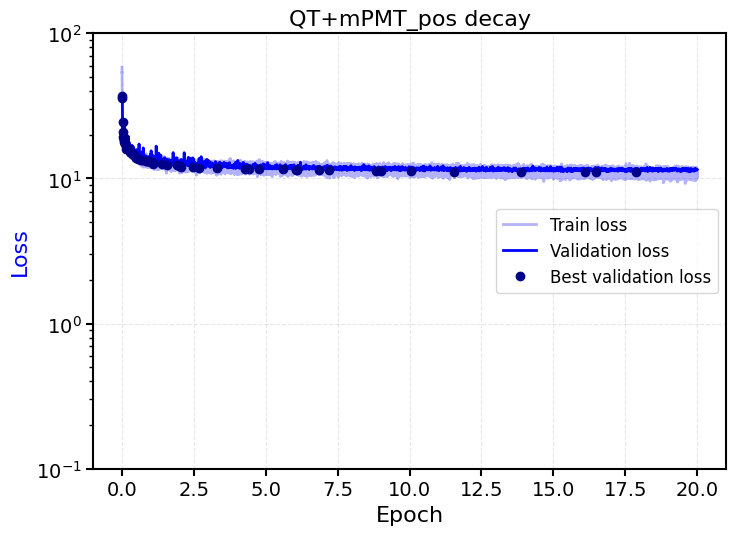

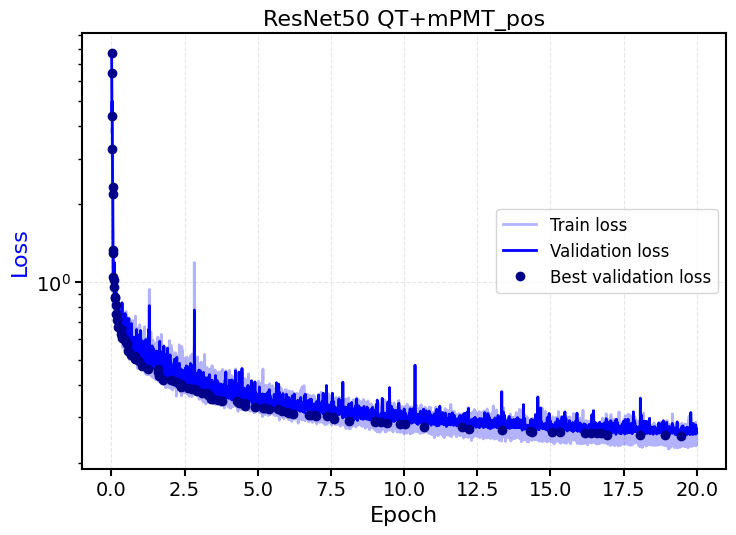

In [39]:
for r in resnet_muon_energy:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')
    ax1.set_ylim(0.1, 100)
    # ax1.set_xlim(10,)
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_position:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_muon_position:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')

## Plots for muon reconstruction

### Plot vertex position reconstruction results

In [40]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']
tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types)

,ResNet50 QT+mPMT_pos
x position resolution [cm],3.32
y position resolution [cm],3.36
z position resolution [cm],3.31
3D position resolution [cm],6.36
Transverse position resolution [cm],5.31
Longitudinal position resolution [cm],2.95
Longitudinal position mean bias [cm],0.26


In [41]:
energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
energy_stat_types = ['resolution', 'resolution']
tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

# infinite values causing nan -- need to fix

,QT+mPMT_pos decay
Momentum fractional error resolution,nan
Momentum residual resolution,nan


In [42]:
# import matplotlib.pyplot as plt
# width = (-20, 20)
# bins = 100
# # bins = 100, ax5_hist) = plt.subplots(2, 1, figsize=(10, 10),
# #                                      gridspec_kw={'height_ratios': [3, 1]},
# #                                      sharex=True)

# fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# # x, y, z residuals
# plot_histograms(resnet_muon_position, 'x_residuals', range=width, bins=bins, x_label="x position residuals [cm]", legend=False, ax=axs[0, 0])
# plot_histograms(resnet_muon_position, 'y_residuals', range=width, bins=bins, x_label="y position residuals [cm]", legend=False, ax=axs[0, 1])
# plot_histograms(resnet_muon_position, 'z_residuals', range=width, bins=bins, x_label="z position residuals [cm]", legend=False, ax=axs[0, 2])

# # 3D, transverse, longitudinal errors
# plot_histograms(resnet_muon_position, 'position_3d_errors', range=(0, 30), bins=bins, x_label="3D distance error [cm]", legend=False, ax=axs[1, 0])
# plot_histograms(resnet_muon_position, 'position_transverse_errors', range=(0, 30), bins=bins, x_label="Transverse error [cm]", legend=False, ax=axs[1, 1])
# plot_histograms(resnet_muon_position, 'position_longitudinal_errors', range=width, bins=bins, x_label="Longitudinal error [cm]", legend=False, ax=axs[1, 2])

# plt.tight_layout()
# plt.show()

# # Create separate legend figure
# fig_legend, ax_legend = plt.subplots(figsize=(8, 2))
# ax_legend.axis('off')

# # Get handles and labels from the first plot (or recreate them)
# handles, labels = axs[0, 0].get_legend_handles_labels()
# ax_legend.legend(handles, labels, loc='center', ncol=min(len(labels), 3), fontsize=12, frameon=False)

# plt.tight_layout()
# plt.show()

In [43]:
# from matplotlib.ticker import MaxNLocator, LogLocator
# matplotlib.rcParams.update({
#     'axes.labelsize': 15,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })


# #should be no return counts

# # Get colors for consistency
# prop_cycle = plt.rcParams['axes.prop_cycle']
# colors = prop_cycle.by_key()['color']

# # Plot 1: Distance to detector wall (towall)
# # fig1, ax1 = plt.subplots(2, 1, figsize=(10, 10), 
# #                                        gridspec_kw={'height_ratios': [3, 1]},
# #                                        sharex=True)
# fig1, ax1 = plt.subplots(figsize = (10,7))

# # Plot resolution profile and get counts
# fig1, ax1 = plot_resolution_profile(
#     resnet_muon_position, 
#     'position_3d_errors', 
#     muon_towall_binning[0],
#     ax=ax1, 
#     x_label="", 
#     y_label="Position resolution [cm]", 
#     legend=None
# )

# handles, labels = ax1.get_legend_handles_labels()
# ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)

# # # Plot histogram of event counts
# # bin_edges = muon_towall_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # n_datasets = len(all_counts)
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax1_hist.bar(positions, counts, width=bar_width*0.9, 
# #                  label=labels[idx], color=colors[idx] if idx < len(colors) else None,
# #                  edgecolor='black', linewidth=0.5)

# # ax1_hist.set_xlabel("Distance to detector wall [cm]")
# # ax1_hist.set_ylabel("# of particles")
# # ax1_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax1_hist.set_yscale('log')
# # ax1_hist.set_yticks([1e3, 1e4])
# # ax1_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# # Plot 2: Distance from detector wall (dwall)
# fig2, ax2 = plt.subplots(figsize = (10,7))

# fig2, ax2 = plot_resolution_profile(
#     resnet_muon_position, 
#     'position_3d_errors', 
#     muon_dwall_binning[0],
#     ax=ax2, 
#     x_label="",
#     y_label="Position resolution [cm]", 
#     legend=None
# )

# handles, labels = ax2.get_legend_handles_labels()
# ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)

# # # Plot histogram
# # bin_edges = muon_dwall_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax2_hist.bar(positions, counts, width=bar_width*0.9, 
# #                  label=labels[idx], color=colors[idx] if idx < len(colors) else None,
# #                  edgecolor='black', linewidth=0.5)

# # ax2_hist.set_xlabel("Distance from detector wall [cm]")
# # ax2_hist.set_ylabel("# of particles")
# # ax2_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax2_hist.set_yticks([1e3, 1e4])
# # ax2_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# # Plot 3: Cosine of Zenith
# fig3, ax3 = plt.subplots(figsize = (10,7))

# fig3, ax3= plot_resolution_profile(
#     resnet_muon_position, 
#     'position_3d_errors', 
#     muon_cos_zenith_binning[0],
#     ax=ax3, 
#     x_label="",
#     y_label="Position resolution [cm]", 
#     legend=None
# )

# handles, labels = ax3.get_legend_handles_labels()
# ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)

# # # Plot histogram
# # bin_edges = muon_cos_zenith_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax3_hist.bar(positions, counts, width=bar_width*0.9, 
# #                  label=labels[idx], color=colors[idx] if idx < len(colors) else None,
# #                  edgecolor='black', linewidth=0.5)

# # ax3_hist.set_xlabel("Cosine of Zenith")
# # ax3_hist.set_ylabel("# of particles")
# # ax3_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax3_hist.set_yticks([1e3, 1e4])
# # ax3_hist.set_yticks([1e4, 2e4])
# # ax3_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# # Plot 4: Azimuth
# fig4, ax4 = plt.subplots(figsize = (10,7))

# fig4, ax4  = plot_resolution_profile(
#     resnet_muon_position, 
#     'position_3d_errors', 
#     muon_azimuth_binning[0],
#     ax=ax4, 
#     x_label="",
#     y_label="Position resolution [cm]", 
#     legend=None
# )

# handles, labels = ax4.get_legend_handles_labels()
# # ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)

# # # Plot histogram
# # bin_edges = muon_azimuth_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax4_hist.bar(positions, counts, width=bar_width*0.9, 
# #                  label=labels[idx], color=colors[idx] if idx < len(colors) else None,
# #                  edgecolor='black', linewidth=0.5)

# # ax4_hist.set_xlabel("Azimuth [°]")
# # ax4_hist.set_ylabel("# of particles")
# # ax4_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax4_hist.set_yticks([1e3, 1e4])
# # ax4_hist.set_yticks([1e4, 2e4])
# # ax4_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# # Plot 5: True muon momentum
# fig5, ax5 = plt.subplots(figsize = (10,7))

# fig5, ax5 = plot_resolution_profile(
#     resnet_muon_position, 
#     'position_3d_errors', 
#     muon_mom_binning[0],
#     ax=ax5, 
#     x_label="",
#     y_label="Position resolution [cm]", 
#     legend=None
# )

# handles, labels = ax5.get_legend_handles_labels()
# # ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)

# # # Plot histogram
# # bin_edges = muon_mom_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax5_hist.bar(positions, counts, width=bar_width*0.9, 
# #                  label=labels[idx], color=colors[idx] if idx < len(colors) else None,
# #                  edgecolor='black', linewidth=0.5)

# # ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# # ax5_hist.set_xlabel("True muon momentum [MeV]")
# # ax5_hist.set_ylabel("# of particles")
# # ax5_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax5_hist.set_yticks([1e3, 1e4])
# # ax5_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# # Create a single legend plot for all figures
# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# plt.tight_layout()


# plt.show()

In [44]:
# all_cuts = cuts_new_geo[h5_keep_idx] & reco_cut

# labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)

# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)

# resnet_muon_position = [
#     WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)]
   

# muon_mom_binning = get_binning(
#     data_new_geo["momentum"][h5_keep_idx][mu_sel],
#     20, 0, 1000
# )

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun muons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx],    
#     true_directions=data_new_geo["directions"][h5_keep_idx],   
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],
#     true_labels=labels,
#     indices=fq_event_ids_new,
#     selection=mu_sel,   
#     linestyle="-",
# )

# # e_sel = all_cuts & (labels == 1)

# # fitqun_e = FitQun1ParticleFit(
# #     fq,
# #     "fiTQun electrons (all cuts)",
# #     true_positions=data_new_geo["positions"][h5_keep_idx],
# #     true_directions=data_new_geo["directions"][h5_keep_idx],
# #     true_momenta=data_new_geo["momentum"][h5_keep_idx],
# #     true_labels=labels,
# #     indices=fq_event_ids_new,
# #     selection=e_sel,
# #     linestyle="-",
# # )


# all_runs_pos = resnet_muon_position + [fitqun_mu]

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning[0], ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

    
    
    
    
    
    
    
    
    
    
    
    
    
    
    

/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1555: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


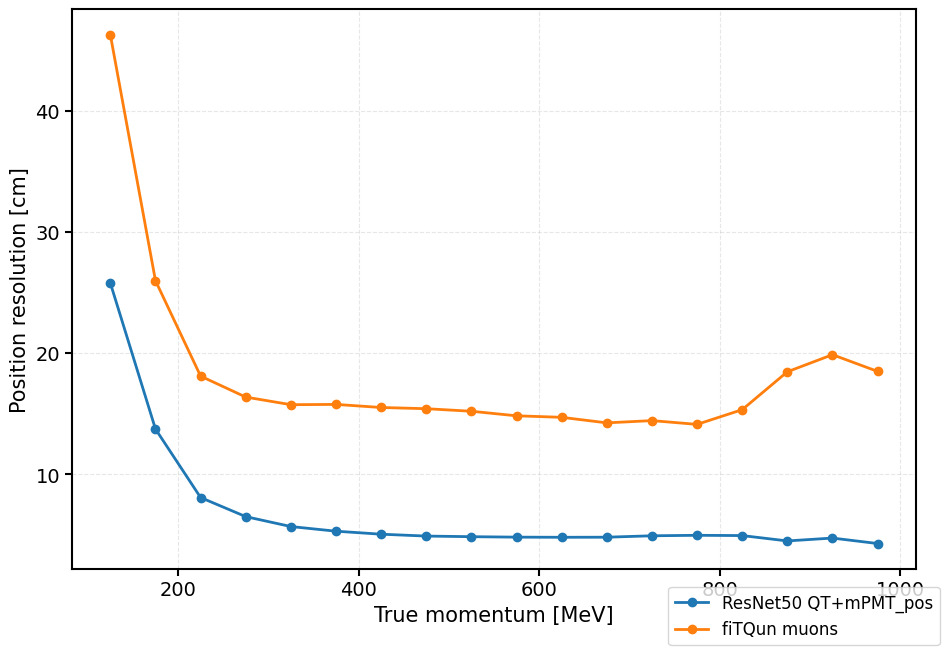

In [45]:
from matplotlib.ticker import MaxNLocator, LogLocator
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# all_cuts = cuts_new_geo[h5_keep_idx] & reco_cut

# dont use reco cut for now

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)

fq_rows = np.arange(len(h5_keep_idx))

mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)

muon_mom_binning = get_binning(
    data_new_geo["momentum"][h5_keep_idx],
    20, 0, 1000
)

# e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
# mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)

resnet_muon_position = WatChMaLPositionRegression(
    outdir_reg + output_pos,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_sel
)

# resnet_muon_position = [
#     WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)]



# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun muons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],   
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],
#     true_labels=labels,
#     indices=fq_keep_idx,
#     selection=mu_sel,  
#     linestyle="-",
# )

mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]  # or your mu_sel

fitqun_mu = FitQun1ParticleFit(
    fq,
    "fiTQun muons",
    true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
    true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
    true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    true_labels=2,                        
    indices=fq_keep_idx[mu_mask_h5],       
    selection=None,
)

# e_sel = all_cuts & (labels == 1)

# fitqun_e = FitQun1ParticleFit(
#     fq,
#     "fiTQun electrons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx][e_sel],
#     true_directions=data_new_geo["directions"][h5_keep_idx][e_sel],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][e_sel],
#     true_labels=labels[e_sel],
#     indices=fq_event_ids_new[e_sel],
#     selection=None,
#     linestyle="-",
# )

# fig1, ax1 = plt.subplots(figsize = (10,7))

# all_runs_pos = [resnet_muon_position, fitqun_mu]

# # for r in range(len(all_runs_pos)):
# #     plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning, ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# fig1, ax1 = plot_resolution_profile([resnet_muon_position], 'position_3d_errors', muon_mom_binning,
#                             ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.show()#

muon_mom_binning = [get_binning(
    data_new_geo["momentum"][h5_keep_idx],
    20, 0, 1000
),
    get_binning(
    data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    20, 0, 1000
)]

# fig2, ax2 = plt.subplots(figsize = (10,7))

# fig2, ax2 = plot_resolution_profile([fitqun_mu], 'position_3d_errors', muon_mom_binning2,
#                             ax=ax2, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.show()

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning[r], ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.sho


all_runs_pos = [resnet_muon_position, fitqun_mu]
fig_r, ax_r = plt.subplots(figsize=(10,7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_mom_binning[r],
        ax=ax_r,                                  # <-- same axis each time
        x_label="True momentum [MeV]",            # or "" if you prefer
        y_label="Position resolution [cm]",
        legend=None
    )

# Optional: one shared legend for all curves (if plot_resolution_profile adds labels)
handles, labels = ax_r.get_legend_handles_labels()
if handles:
    fig_r.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

fig_r.tight_layout()

AttributeError: 'list' object has no attribute 'plot_args'

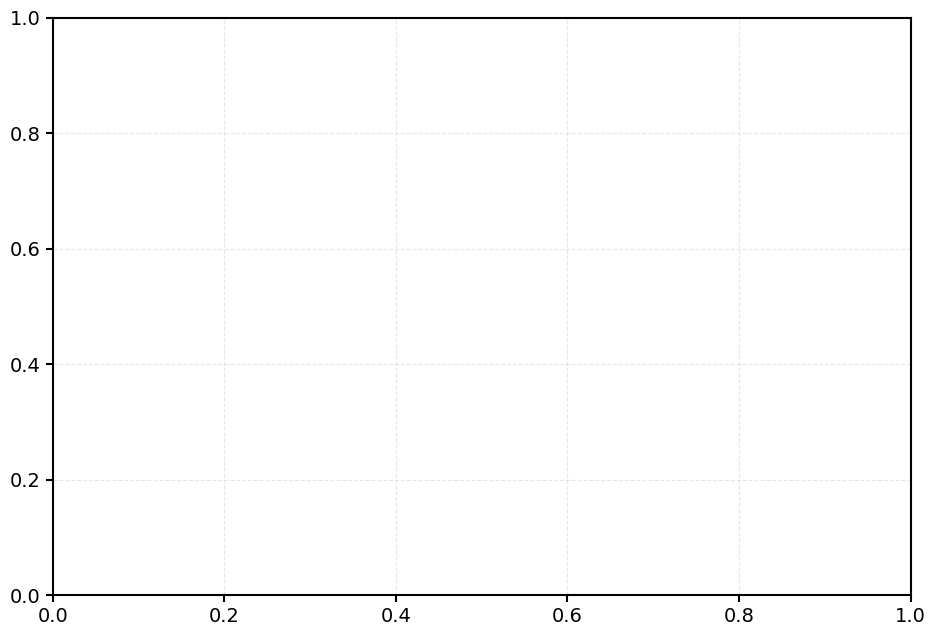

In [52]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 

muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]

all_runs_pos = [resnet_muon_position, fitqun_mu]

fig1, ax1 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_towall_binning[r],       
        ax=ax1,
        x_label="Distance to detector wall [cm]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
fig1.tight_layout()

handles, labels = ax1.get_legend_handles_labels()


fig2, ax2 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_dwall_binning[r],
        ax=ax2,
        x_label="Distance from detector wall [cm]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
fig2.tight_layout()

handles, labels = ax2.get_legend_handles_labels()


# -----------------------
# Plot 3: cos zenith
# -----------------------
fig3, ax3 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_cos_zenith_binning[r],
        ax=ax3,
        x_label="Cosine of Zenith",
        y_label="Position resolution [cm]",
        legend=None
    )

ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
fig3.tight_layout()

handles, labels = ax3.get_legend_handles_labels()


fig4, ax4 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_azimuth_binning[r],
        ax=ax4,
        x_label="Azimuth [°]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
fig4.tight_layout()

handles, labels = ax4.get_legend_handles_labels()


fig5, ax5 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_mom_binning[r],
        ax=ax5,
        x_label="True muon momentum [MeV]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
fig5.tight_layout()

handles, labels = ax5.get_legend_handles_labels()


# -----------------------
# Single legend figure (shared)
# -----------------------
fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
ax_legend.axis('off')
ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
fig_legend.tight_layout()

plt.show()


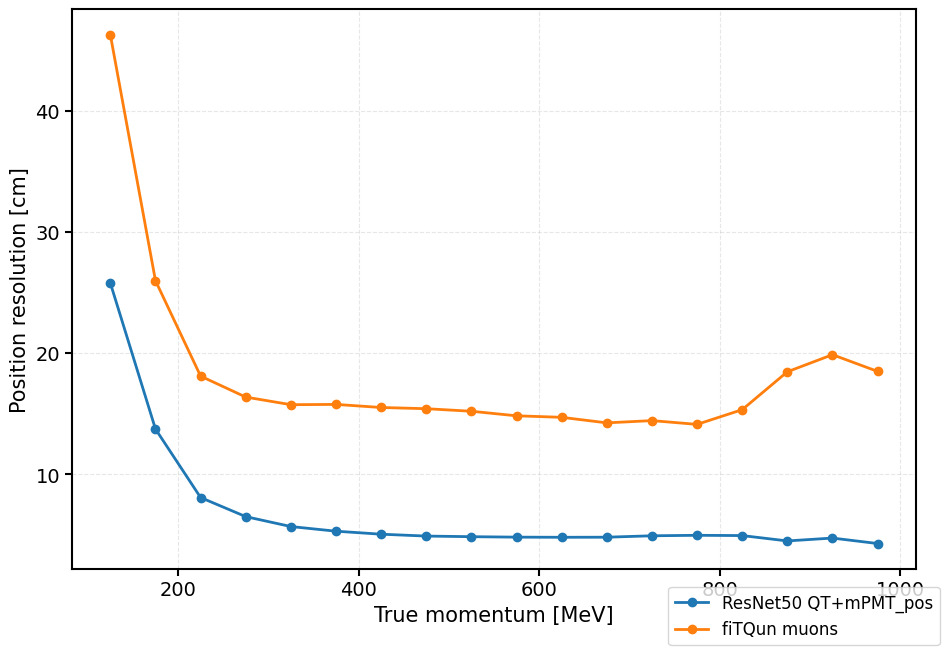

In [50]:
from matplotlib.ticker import MaxNLocator, LogLocator
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# all_cuts = cuts_new_geo[h5_keep_idx] & reco_cut

# dont use reco cut for now

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)

fq_rows = np.arange(len(h5_keep_idx))

mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)

muon_mom_binning = get_binning(
    data_new_geo["momentum"][h5_keep_idx],
    20, 0, 1000
)

# e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
# mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)

resnet_muon_position = WatChMaLPositionRegression(
    outdir_reg + output_pos,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_sel
)

# resnet_muon_position = [
#     WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)]



# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun muons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],   
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],
#     true_labels=labels,
#     indices=fq_keep_idx,
#     selection=mu_sel,  
#     linestyle="-",
# )

mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]  # or your mu_sel

fitqun_mu = FitQun1ParticleFit(
    fq,
    "fiTQun muons",
    true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
    true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
    true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    true_labels=2,                        
    indices=fq_keep_idx[mu_mask_h5],       
    selection=None,
)

# e_sel = all_cuts & (labels == 1)

# fitqun_e = FitQun1ParticleFit(
#     fq,
#     "fiTQun electrons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx][e_sel],
#     true_directions=data_new_geo["directions"][h5_keep_idx][e_sel],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][e_sel],
#     true_labels=labels[e_sel],
#     indices=fq_event_ids_new[e_sel],
#     selection=None,
#     linestyle="-",
# )

# fig1, ax1 = plt.subplots(figsize = (10,7))

# all_runs_pos = [resnet_muon_position, fitqun_mu]

# # for r in range(len(all_runs_pos)):
# #     plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning, ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# fig1, ax1 = plot_resolution_profile([resnet_muon_position], 'position_3d_errors', muon_mom_binning,
#                             ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.show()#

muon_mom_binning = [get_binning(
    data_new_geo["momentum"][h5_keep_idx],
    20, 0, 1000
),
    get_binning(
    data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    20, 0, 1000
)]

# fig2, ax2 = plt.subplots(figsize = (10,7))

# fig2, ax2 = plot_resolution_profile([fitqun_mu], 'position_3d_errors', muon_mom_binning2,
#                             ax=ax2, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.show()

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning[r], ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

# plt.sho

fig_r, ax_r = plt.subplots(figsize=(10,7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_mom_binning[r],
        ax=ax_r,                                  # <-- same axis each time
        x_label="True momentum [MeV]",            # or "" if you prefer
        y_label="Position resolution [cm]",
        legend=None
    )

# Optional: one shared legend for all curves (if plot_resolution_profile adds labels)
handles, labels = ax_r.get_legend_handles_labels()
if handles:
    fig_r.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

fig_r.tight_layout()

In [48]:
# print(len(resnet_muon_position[0].get_quantity("position_3d_errors")))
# print(len(fitqun_mu.get_quantity("position_3d_errors")))
# print(len(muon_mom_binning[1]))

In [51]:
all_cuts = cuts_new_geo[h5_keep_idx] & reco_cut

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)

mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)

resnet_muon_position = [
    WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)]
   

muon_mom_binning = get_binning(
    data_new_geo["momentum"][h5_keep_idx][mu_sel],
    20, 0, 1000
)

fitqun_mu = FitQun1ParticleFit(
    fq,
    "fiTQun muons (all cuts)",
    true_positions=data_new_geo["positions"][h5_keep_idx],    
    true_directions=data_new_geo["directions"][h5_keep_idx],   
    true_momenta=data_new_geo["momentum"][h5_keep_idx],
    true_labels=labels,
    indices=fq_event_ids_new,
    selection=mu_sel,   
    linestyle="-",
)

# e_sel = all_cuts & (labels == 1)

# fitqun_e = FitQun1ParticleFit(
#     fq,
#     "fiTQun electrons (all cuts)",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],
#     true_labels=labels,
#     indices=fq_event_ids_new,
#     selection=e_sel,
#     linestyle="-",
# )


all_runs_pos = resnet_muon_position + [fitqun_mu]

for r in range(len(all_runs_pos)):
    plot_resolution_profile([all_runs_pos[r]], 'position_3d_errors', muon_mom_binning[0], ax=ax1, x_label="", y_label="Position resolution [cm]", legend=None)

    
    
    
    
    
    
    
    
    
    
    
    
    
    
    

ValueError: shape mismatch: value array of shape (2338955,3) could not be broadcast to indexing result of shape (1183264,3)

In [ ]:
import numpy as np

# --- 0) Load WatChMaL event indices (the axis WatChMaL predictions live on)
wdir = outdir_reg + output_pos
w_idx = np.load(wdir + "/outputs/indices.npy")          # global event ids for WatChMaL outputs

# --- 1) Build a COMMON event list between WatChMaL and fiTQun (global event ids)
# fq_event_ids_new should be the global ids for fiTQun outputs (as you used in classification)
common_idx = np.intersect1d(w_idx, fq_event_ids_new)

# --- 2) Build truth arrays on the SAME common axis (use full data_new_geo indexing)
true_pos = data_new_geo["positions"][common_idx]
true_dir = data_new_geo["directions"][common_idx]
true_mom = data_new_geo["momentum"][common_idx]
true_lab = np.asarray(data_new_geo["labels"][common_idx]).astype(int)
true_cuts = cuts_new_geo[common_idx]

# --- 3) Selection for muons + physics cuts (NO reco_cut here)
mu_sel = (true_lab == 2) & true_cuts

# --- 4) Momentum binning on the SAME common axis (do NOT slice here; selection is applied later)
mom_binning = get_binning(true_mom, 20, 0, 1000)

# --- 5) Construct WatChMaL position run on the common axis
# remove selection if it exists in your args dicts
muon_args_no_sel  = {k: v for k, v in muon_args_new_geo.items() if k != "selection"}
resnet_args_no_sel = {k: v for k, v in resnet_args.items() if k != "selection"}

watchmal_mu_pos = WatChMaLPositionRegression(
    wdir,
    "ResNet50 QT+mPMT_pos",
    true_positions=true_pos,
    true_directions=true_dir,
    indices=common_idx,
    selection=mu_sel,
    **muon_args_no_sel,
    **resnet_args_no_sel,
)

# --- 6) Construct fiTQun run on the SAME common axis
fitqun_mu_pos = FitQun1ParticleFit(
    fq,
    "fiTQun muons (physics cuts)",
    true_positions=true_pos,
    true_directions=true_dir,
    true_momenta=true_mom,
    true_labels=true_lab,
    indices=common_idx,
    selection=mu_sel,
    linestyle="-",
)

# --- 7) Plot: position resolution binned in true momentum (muons)
plot_resolution_profile(
    [watchmal_mu_pos, fitqun_mu_pos],
    "position_3d_errors",
    mom_binning,
    ax=ax1,
    x_label="True momentum [MeV]",
    y_label="Position resolution [cm]",
    legend=None,
)

# --- Optional sanity checks (should all match)
print("COMMON axis:", len(common_idx))
print("WatChMaL values:", len(watchmal_mu_pos.get_quantity("position_3d_errors")))
print("fiTQun values:", len(fitqun_mu_pos.get_quantity("position_3d_errors")))
print("bin ids:", len(mom_binning[1]))


In [ ]:
# Plot 1: Distance to detector wall (towall) - Transverse
fig1, ax1 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_transverse_errors', 
                           muon_towall_binning[r], ax=ax1, 
                           x_label="Distance to detector wall [cm]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='best', fontsize=12)
ax1.set_title("Muon Transverse Position Resolution vs Distance to Wall", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 2: Distance from detector wall (dwall) - Transverse
fig2, ax2 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_transverse_errors', 
                           muon_dwall_binning[r], ax=ax2, 
                           x_label="Distance from detector wall [cm]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='best', fontsize=12)
ax2.set_title("Muon Transverse Position Resolution vs Distance from Wall", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 3: Cosine of Zenith - Transverse
fig3, ax3 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_transverse_errors', 
                           muon_cos_zenith_binning[r], ax=ax3, 
                           x_label="Cosine of Zenith", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles, labels, loc='best', fontsize=12)
ax3.set_title("Muon Transverse Position Resolution vs Cosine of Zenith", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 4: Azimuth - Transverse
fig4, ax4 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_transverse_errors', 
                           muon_azimuth_binning[r], ax=ax4, 
                           x_label="Azimuth [°]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax4.get_legend_handles_labels()
ax4.legend(handles, labels, loc='best', fontsize=12)
ax4.set_title("Muon Transverse Position Resolution vs Azimuth", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 5: True muon momentum - Transverse
fig5, ax5 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_transverse_errors', 
                           muon_mom_binning[r], ax=ax5, 
                           x_label="True muon momentum [MeV]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax5.get_legend_handles_labels()
ax5.legend(handles, labels, loc='best', fontsize=12)
ax5.set_title("Muon Transverse Position Resolution vs Momentum", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
get_binning(data_fixed['towall'][mu_idxs_fixed_geo], 30, 50, 400)

In [ ]:
# Plot 1: Distance to detector wall (towall) - Longitudinal
fig1, ax1 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_longitudinal_errors', 
                           muon_towall_binning[r], ax=ax1, 
                           x_label="Distance to detector wall [cm]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='best', fontsize=12)
ax1.set_title("Muon Longitudinal Position Resolution vs Distance to Wall", fontsize=16)
plt.tight_layout()
plt.show()


# Plot 2: Distance from detector wall (dwall) - Longitudinal
fig2, ax2 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_longitudinal_errors', 
                           muon_dwall_binning[r], ax=ax2, 
                           x_label="Distance from detector wall [cm]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='best', fontsize=12)
ax2.set_title("Muon Longitudinal Position Resolution vs Distance from Wall", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 3: Cosine of Zenith - Longitudinal
fig3, ax3 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_longitudinal_errors', 
                           muon_cos_zenith_binning[r], ax=ax3, 
                           x_label="Cosine of Zenith", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles, labels, loc='best', fontsize=12)
ax3.set_title("Muon Longitudinal Position Resolution vs Cosine of Zenith", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 4: Azimuth - Longitudinal
fig4, ax4 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_longitudinal_errors', 
                           muon_azimuth_binning[r], ax=ax4, 
                           x_label="Azimuth [°]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax4.get_legend_handles_labels()
ax4.legend(handles, labels, loc='best', fontsize=12)
ax4.set_title("Muon Longitudinal Position Resolution vs Azimuth", fontsize=16)
plt.tight_layout()
plt.show()

# Plot 5: True muon momentum - Longitudinal
fig5, ax5 = plt.subplots(figsize=(10, 6))

for r in range(len(resnet_muon_position)):
    plot_resolution_profile([resnet_muon_position[r]], 'position_longitudinal_errors', 
                           muon_mom_binning[r], ax=ax5, 
                           x_label="True muon momentum [MeV]", 
                           y_label="Position resolution [cm]", legend=None)

handles, labels = ax5.get_legend_handles_labels()
ax5.legend(handles, labels, loc='best', fontsize=12)
ax5.set_title("Muon Longitudinal Position Resolution vs Momentum", fontsize=16)
plt.tight_layout()
plt.show()

### Plot particle direction reconstruction results

In [ ]:
tabulate_statistics(resnet_muon_direction, 'direction_errors', "Direction resolution [°]", statistic='resolution')

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# Direction Resolution Plots
# (Uses the add_bin_counts function defined in previous cell)

# Plot 1: Distance to detector wall
fig1, (ax1, ax1_table) = plt.subplots(2, 1, figsize=(10, 10), 
                                       gridspec_kw={'height_ratios': [3, 1]})

for r in range(len(resnet_muon_direction)):
    plot_resolution_profile([resnet_muon_direction[r]], 'direction_errors', 
                           muon_towall_binning, ax=ax1, 
                           x_label="Distance to detector wall [cm]", 
                           y_label="Direction resolution [°]", legend=None)

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='best', fontsize=12)
ax1.set_title("Muon Direction Resolution vs Distance to Wall", fontsize=16)

data_list = [resnet_muon_direction[r].get_quantity('direction_errors') for r in range(len(resnet_muon_direction))]
add_bin_counts(ax1_table, muon_towall_binning, data_list, labels)
plt.tight_layout()
plt.show()

# Plot 2: Distance from detector wall
fig2, (ax2, ax2_table) = plt.subplots(2, 1, figsize=(10, 10), 
                                       gridspec_kw={'height_ratios': [3, 1]})

for r in range(len(resnet_muon_direction)):
    plot_resolution_profile([resnet_muon_direction[r]], 'direction_errors', 
                           muon_dwall_binning, ax=ax2, 
                           x_label="Distance from detector wall [cm]", 
                           y_label="Direction resolution [°]", legend=None)

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='best', fontsize=12)
ax2.set_title("Muon Direction Resolution vs Distance from Wall", fontsize=16)

data_list = [resnet_muon_direction[r].get_quantity('direction_errors') for r in range(len(resnet_muon_direction))]
add_bin_counts(ax2_table, muon_dwall_binning, data_list, labels)
plt.tight_layout()
plt.show()

# Plot 3: Cosine of Zenith
fig3, (ax3, ax3_table) = plt.subplots(2, 1, figsize=(10, 10), 
                                       gridspec_kw={'height_ratios': [3, 1]})

for r in range(len(resnet_muon_direction)):
    plot_resolution_profile([resnet_muon_direction[r]], 'direction_errors', 
                           muon_cos_zenith_binning, ax=ax3, 
                           x_label="Cosine of Zenith", 
                           y_label="Direction resolution [°]", legend=None)

handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles, labels, loc='best', fontsize=12)
ax3.set_title("Muon Direction Resolution vs Cosine of Zenith", fontsize=16)

data_list = [resnet_muon_direction[r].get_quantity('direction_errors') for r in range(len(resnet_muon_direction))]
add_bin_counts(ax3_table, muon_cos_zenith_binning, data_list, labels)
plt.tight_layout()
plt.show()

# Plot 4: Azimuth
fig4, (ax4, ax4_table) = plt.subplots(2, 1, figsize=(10, 10), 
                                       gridspec_kw={'height_ratios': [3, 1]})

for r in range(len(resnet_muon_direction)):
    plot_resolution_profile([resnet_muon_direction[r]], 'direction_errors', 
                           muon_azimuth_binning, ax=ax4, 
                           x_label="Azimuth [°]", 
                           y_label="Direction resolution [°]", legend=None)

handles, labels = ax4.get_legend_handles_labels()
ax4.legend(handles, labels, loc='best', fontsize=12)
ax4.set_title("Muon Direction Resolution vs Azimuth", fontsize=16)

data_list = [resnet_muon_direction[r].get_quantity('direction_errors') for r in range(len(resnet_muon_direction))]
add_bin_counts(ax4_table, muon_azimuth_binning, data_list, labels)
plt.tight_layout()
plt.show()

# Plot 5: True muon momentum
fig5, (ax5, ax5_table) = plt.subplots(2, 1, figsize=(10, 10), 
                                       gridspec_kw={'height_ratios': [3, 1]})

for r in range(len(resnet_muon_direction)):
    plot_resolution_profile([resnet_muon_direction[r]], 'direction_errors', 
                           muon_mom_binning, ax=ax5, 
                           x_label="True muon momentum [MeV]", 
                           y_label="Direction resolution [°]", legend=None)

handles, labels = ax5.get_legend_handles_labels()
ax5.legend(handles, labels, loc='best', fontsize=12)
ax5.set_title("Muon Direction Resolution vs Momentum", fontsize=16)

data_list = [resnet_muon_direction[r].get_quantity('direction_errors') for r in range(len(resnet_muon_direction))]
add_bin_counts(ax5_table, muon_mom_binning, data_list, labels)
plt.tight_layout()
plt.show()

### Plot particle energy reconstruction results

In [ ]:
# Use a lambda function to get the fractional resolution in percentage
energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100
momentum_stats = ['energy_residuals', 'momentum_residuals', 'energy_residuals', 'momentum_residuals', 
                  energy_percentage_errors, momentum_percentage_errors, energy_percentage_errors, momentum_percentage_errors]
momentum_stat_labels = ["Energy resolution [MeV]", "Momentum resolution [MeV]", "Energy mean bias [MeV]", "Momentum mean bias [MeV]",
                        "Energy resolution [%]", "Momentum resolution [%]", "Energy mean bias [%]", "Momentum mean bias [%]"]
momentum_stat_types = ['resolution', 'resolution', 'mean', 'mean','resolution', 'resolution', 'mean', 'mean']
tabulate_statistics(resnet_muon_energy, momentum_stats, momentum_stat_labels, momentum_stat_types)

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(resnet_muon_energy)):
    plot_resolution_profile([resnet_muon_energy[r]], 'momentum_residuals', muon_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], 'momentum_residuals', muon_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], 'momentum_residuals', muon_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], 'momentum_residuals', muon_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], 'momentum_residuals', muon_mom_binning[r], ax=ax2[2,0], x_label="True muon momentum [MeV]", y_label="Momentum resolution [MeV]", legend=None)
    
    

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)


for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')
fig2.delaxes(ax2[2, 1])
fig2.supylabel("Muon momentum resolution [MeV]", fontsize=16, x=0.05)
fig2.suptitle("Muon Momentum Resolution", fontsize=20, y=0.918)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()
plt.show()


In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(resnet_muon_energy)):

    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_mom_binning[r], ax=ax2[2,0], x_label="True muon momentum [MeV]", y_label="Momentum resolution [%]", legend=None)
handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

y_ticks_1 = np.arange(0, 11, 2)
y_ticks_2 = np.arange(1, 5, 1)
y_ticks_3 = np.arange(0, 46, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)


fig2.delaxes(ax2[2, 1])
fig2.supylabel("Muon momentum resolution [%]", fontsize=16)
fig2.suptitle("Muon momentum resolution [%]", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,5))
for r in range(len(resnet_muon_energy)):
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_mom_binning[r], ax=ax, x_label="True muon momentum [MeV]", y_label="Momentum resolution [%]", legend=None, errors=True)   
plt.show()

#plot legend on separate axis without white space
fig_legend, ax_legend = plt.subplots(1,1, figsize=(6,5))
handles, labels = ax.get_legend_handles_labels()
fig_legend.legend(handles, labels, loc='center', fontsize=12)
plt.axis('off')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,5))
#Plot against azimuth 
for r in range(len(resnet_muon_energy)):
    plot_resolution_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_azimuth_binning[r], ax=ax, x_label="Azimuth [°]", y_label="Momentum resolution [%]", legend=None, errors=False)   
plt.show()

#plot legend on separate axis without white space
fig_legend, ax_legend = plt.subplots(1,1, figsize=(6,5))
handles, labels = ax.get_legend_handles_labels()
fig_legend.legend(handles, labels, loc='center', fontsize=12)
plt.axis('off')
plt.show()

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)

for r in range(len(resnet_muon_energy)):
    plot_bias_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_towall_binning[r], ax=ax2[0,0],
                      x_label="Distance to detector wall [cm]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_mom_binning[r], ax=ax2[2,0],
                      x_label="True muon momentum [MeV]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_cos_zenith_binning[r], ax=ax2[1,0],
                      x_label="Cosine of Zenith", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_azimuth_binning[r], ax=ax2[1,1],
                      x_label="Azimuth [°]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([resnet_muon_energy[r]], momentum_percentage_errors, muon_dwall_binning[r], ax=ax2[0,1],
                      x_label="Distance from detector wall [cm]", y_label="Momentum bias [%]",
                      legend=None, errors=True)

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

y_ticks_1 = np.arange(-1, 2, 0.5)
y_ticks_2 = np.arange(-1, 3, 0.5)
y_ticks_3 = np.arange(-30, 10, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)

fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

fig2.delaxes(ax2[2, 1])
fig2.supylabel("Momentum bias [%]", fontsize=16)
fig2.suptitle("Muon momentum bias [%]", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()
plt.show()


In [ ]:
# ##energy

# # doesnt have a return counts part

# from matplotlib.ticker import MaxNLocator, LogLocator
# matplotlib.rcParams.update({
#     'axes.labelsize': 15,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# prop_cycle = plt.rcParams['axes.prop_cycle']
# colors = prop_cycle.by_key()['color']

# fig1, ax1 = plt.subplots(figsize=(10, 7))

# fig1, ax1 = plot_resolution_profile(
#     resnet_muon_energy,
#     'energy_residuals',
#     muon_towall_binning[0],
#     ax=ax1,
#     x_label="",
#     y_label="Energy resolution [MeV]",
#     legend=None
# )

# handles, labels = ax1.get_legend_handles_labels()
# ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)

# # bin_edges = muon_towall_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # n_datasets = len(all_counts)
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax1_hist.bar(
# #         positions, counts, width=bar_width*0.9,
# #         label=labels[idx],
# #         color=colors[idx] if idx < len(colors) else None,
# #         edgecolor='black', linewidth=0.5
# #     )

# # ax1_hist.set_xlabel("Distance to detector wall [cm]")
# # ax1_hist.set_ylabel("# of particles")
# # ax1_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax1_hist.set_yscale('log')
# # ax1_hist.set_yticks([1e3, 1e4])
# # ax1_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# fig2, ax2 = plt.subplots(figsize=(10, 7))

# fig2, ax2 = plot_resolution_profile(
#     resnet_muon_energy,
#     'energy_residuals',
#     muon_dwall_binning[0],
#     ax=ax2,
#     x_label="",
#     y_label="Energy resolution [MeV]",
#     legend=None
# )

# handles, labels = ax2.get_legend_handles_labels()
# ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)

# # bin_edges = muon_dwall_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax2_hist.bar(
# #         positions, counts, width=bar_width*0.9,
# #         label=labels[idx],
# #         color=colors[idx] if idx < len(colors) else None,
# #         edgecolor='black', linewidth=0.5
# #     )

# # ax2_hist.set_xlabel("Distance from detector wall [cm]")
# # ax2_hist.set_ylabel("# of particles")
# # ax2_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax2_hist.set_yticks([1e3, 1e4])
# # ax2_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# fig3, ax3 = plt.subplots(figsize=(10, 7))

# fig3, ax3 = plot_resolution_profile(
#     resnet_muon_energy,
#     'energy_residuals',
#     muon_cos_zenith_binning[0],
#     ax=ax3,
#     x_label="",
#     y_label="Energy resolution [MeV]",
#     legend=None
# )

# handles, labels = ax3.get_legend_handles_labels()
# ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)

# # bin_edges = muon_cos_zenith_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax3_hist.bar(
# #         positions, counts, width=bar_width*0.9,
# #         label=labels[idx],
# #         color=colors[idx] if idx < len(colors) else None,
# #         edgecolor='black', linewidth=0.5
# #     )

# # ax3_hist.set_xlabel("Cosine of Zenith")
# # ax3_hist.set_ylabel("# of particles")
# # ax3_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax3_hist.set_yticks([1e4, 2e4])
# # ax3_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# fig4, ax4  = plt.subplots(figsize=(10, 7))

# fig4, ax4 = plot_resolution_profile(
#     resnet_muon_energy,
#     'energy_residuals',
#     muon_azimuth_binning[0],
#     ax=ax4,
#     x_label="",
#     y_label="Energy resolution [MeV]",
#     legend=None
# )

# handles, labels = ax4.get_legend_handles_labels()
# ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)

# # bin_edges = muon_azimuth_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax4_hist.bar(
# #         positions, counts, width=bar_width*0.9,
# #         label=labels[idx],
# #         color=colors[idx] if idx < len(colors) else None,
# #         edgecolor='black', linewidth=0.5
# #     )

# # ax4_hist.set_xlabel("Azimuth [°]")
# # ax4_hist.set_ylabel("# of particles")
# # ax4_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax4_hist.set_yticks([1e4, 2e4])
# # ax4_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# fig5, ax5 = plt.subplots(figsize=(10, 7))

# fig5, ax5 = plot_resolution_profile(
#     resnet_muon_energy,
#     'energy_residuals',
#     muon_mom_binning[0],
#     ax=ax5,
#     x_label="",
#     y_label="Energy resolution [MeV]",
#     legend=None
# )

# handles, labels = ax5.get_legend_handles_labels()
# ax5.set_title("Muon Energy Resolution vs Momentum", fontsize=16)

# # bin_edges = muon_mom_binning[0][0]
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# # bin_width = bin_edges[1] - bin_edges[0]
# # bar_width = bin_width / (n_datasets + 1)

# # for idx, counts in enumerate(all_counts):
# #     offset = (idx - n_datasets/2 + 0.5) * bar_width
# #     positions = bin_centers + offset
# #     ax5_hist.bar(
# #         positions, counts, width=bar_width*0.9,
# #         label=labels[idx],
# #         color=colors[idx] if idx < len(colors) else None,
# #         edgecolor='black', linewidth=0.5
# #     )

# # ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# # ax5_hist.set_xlabel("True muon momentum [MeV]")
# # ax5_hist.set_ylabel("# of particles")
# # ax5_hist.set_xlim(bin_edges[0], bin_edges[-1])
# # ax5_hist.set_yticks([1e3, 1e4])
# # ax5_hist.grid(True, alpha=0.3, axis='y')
# # plt.tight_layout()
# # plt.show()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# plt.tight_layout()
# plt.show()

### Table of all results for muons

In [ ]:
resnet_muon_best_runs = [
    resnet_muon_position,
    resnet_muon_direction,
    resnet_muon_energy
]
muon_runs = [
    CombinedRegressionRun(resnet_muon_best_runs, "ResNet best", **resnet_args, selection=mu_cuts)
]

In [ ]:
all_stats = [
    'position_3d_errors',
    'position_transverse_errors',
    'position_longitudinal_errors',
    'position_longitudinal_errors',
    'direction_errors',
    'momentum_residuals',
    'momentum_residuals',
    momentum_percentage_errors,
    momentum_percentage_errors,
]
all_stat_labels = [
    "3D position resolution [cm]",
    "Transverse position resolution [cm]",
    "Longitudinal position resolution [cm]",
    "Longitudinal position mean bias [cm]",
    "Direction resolution [°]",
    "Momentum resolution [MeV]",
    "Momentum mean bias [MeV]",
    "Momentum resolution [%]",
    "Momentum mean bias [%]",
]
all_stat_types = [
    'resolution',
    'resolution',
    'resolution',
    'mean',
    'resolution',
    'resolution',
    'mean',
    'resolution',
    'mean',
]
tabulate_statistics(muon_runs, all_stats, all_stat_labels, all_stat_types)

## Plots for electron reconstruction

### Plot vertex position reconstruction results

In [ ]:
tabulate_statistics(test_electron_pos, position_stats, position_stat_labels, position_stat_types)

In [ ]:
import matplotlib.pyplot as plt
width = (-40, 40)
bins = 100

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# x, y, z residuals
plot_histograms(test_electron_pos, 'x_residuals', range=width, bins=bins, x_label="x position residuals [cm]", legend=True, ax=axs[0, 0])
plot_histograms(test_electron_pos, 'y_residuals', range=width, bins=bins, x_label="y position residuals [cm]", legend=False, ax=axs[0, 1])
plot_histograms(test_electron_pos, 'z_residuals', range=width, bins=bins, x_label="z position residuals [cm]", legend=False, ax=axs[0, 2])

# 3D, transverse, longitudinal errors
plot_histograms(test_electron_pos, 'position_3d_errors', range=(0, 40), bins=bins, x_label="3D distance error [cm]", legend=False, ax=axs[1, 0])
plot_histograms(test_electron_pos, 'position_transverse_errors', range=(0, 40), bins=bins, x_label="Transverse error [cm]", legend=False, ax=axs[1, 1])
plot_histograms(test_electron_pos, 'position_longitudinal_errors', range=width, bins=bins, x_label="Longitudinal error [cm]", legend=False, ax=axs[1, 2])

axs[0, 0].legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(test_electron_pos)):
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]",  legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Position resolution [cm]", legend=None)


# Remove all y-labels except the first column (ax2[0,0], ax2[1,0], ax2[2,0])
for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
y_ticks_1 = np.arange(0, 26, 5)
y_ticks_2 = np.arange(0, 26, 5)
y_ticks_3 = np.arange(0, 31, 10)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)

fig2.delaxes(ax2[2, 1])
fig2.supylabel("Electron position resolution [cm]", fontsize=16)
fig2.suptitle("Electron position resolution", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()


In [ ]:
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 5), sharey='row', dpi=100)
for r in [0,1,4]:
    plot_resolution_profile([test_electron_pos[r]], 'position_3d_errors', electron_mom_binning[r], ax=ax2, x_label="True electron momentum [MeV]", y_label="Position resolution [cm]", legend=None, errors=True)
    
ax2.set_yticks(np.arange(0, 30, 5))
ax2.set_xticks(np.arange(0, 1100, 200))

ax2.set_ylim(0,25)


plt.show()

#plot legend on separate axis without white space
fig_legend, ax_legend = plt.subplots(1,1, figsize=(12,6))
handles, labels = ax2.get_legend_handles_labels()
fig_legend.legend(handles, labels, loc='center', fontsize=50)
plt.axis('off')
plt.show()
    

In [ ]:
fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(test_electron_pos)):
    plot_resolution_profile([test_electron_pos[r]], 'position_transverse_errors', electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall[cm]", y_label="Transverse position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_transverse_errors', electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Transverse position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_transverse_errors', electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Transverse position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_transverse_errors', electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Transverse position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_transverse_errors', electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Transverse position resolution [cm]", legend=None)


for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

fig2.delaxes(ax2[2, 1])

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
y_ticks_1 = np.arange(0, 26, 5)
y_ticks_2 = np.arange(0, 21, 5)
y_ticks_3 = np.arange(0, 30, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)
fig2.supylabel("Electron transverse position resolution [cm]", fontsize=16)
fig2.suptitle("Electron transverse position resolution", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()


In [ ]:
fig2, ax2= plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)

for r in range(len(test_muon_pos)):
    plot_resolution_profile([test_electron_pos[r]], 'position_longitudinal_errors', electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Longitudinal position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_longitudinal_errors', electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Longitudinal position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_longitudinal_errors', electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Longitudinal position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_longitudinal_errors', electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Longitudinal position resolution [cm]", legend=None)
    plot_resolution_profile([test_electron_pos[r]], 'position_longitudinal_errors', electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Longitudinal position resolution [cm]", legend=None)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

fig2.delaxes(ax2[2, 1])

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
y_ticks_1 = np.arange(0, 21, 5)
y_ticks_2 = np.arange(0, 11, 2)
y_ticks_3 = np.arange(0, 16, 2)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)
        

fig2.supylabel("Electron longitudinal position resolution [cm]", fontsize=16)
fig2.suptitle("Electron longitudinal position resolution", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()


### Plot particle direction reconstruction results

In [ ]:
tabulate_statistics(test_electron_dir, 'direction_errors', "Direction resolution [°]", statistic='resolution')

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(test_electron_dir)):
    plot_resolution_profile([test_electron_dir[r]], 'direction_errors', electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution [°]", legend=None)
    plot_resolution_profile([test_electron_dir[r]], 'direction_errors', electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Direction resolution [°]", legend=None)
    plot_resolution_profile([test_electron_dir[r]], 'direction_errors', electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Direction resolution [°]", legend=None)
    plot_resolution_profile([test_electron_dir[r]], 'direction_errors', electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Direction resolution [°]", legend=None)
    plot_resolution_profile([test_electron_dir[r]], 'direction_errors', electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Direction resolution [°]", legend=None)

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
y_ticks_1 = np.arange(0, 16, 2)
y_ticks_2 = np.arange(0, 11, 2)
y_ticks_3 = np.arange(0, 25, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)


for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')
fig2.delaxes(ax2[2, 1])

fig2.supylabel("Electron direction resolution [°]", fontsize=16, x=0.04)
fig2.suptitle("Electron direction resolution", fontsize=20, y=0.918)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()


### Plot particle energy/momentum reconstruction results

In [ ]:
# Use a lambda function to get the fractional resolution in percentage
energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100
momentum_stats = ['energy_residuals', 'momentum_residuals', 'energy_residuals', 'momentum_residuals', 
                  energy_percentage_errors, momentum_percentage_errors, energy_percentage_errors, momentum_percentage_errors]
momentum_stat_labels = ["Energy resolution [MeV]", "Momentum resolution [MeV]", "Energy mean bias [MeV]", "Momentum mean bias [MeV]",
                        "Energy resolution [%]", "Momentum resolution [%]", "Energy mean bias [%]", "Momentum mean bias [%]"]
momentum_stat_types = ['resolution', 'resolution', 'mean', 'mean','resolution', 'resolution', 'mean', 'mean']
tabulate_statistics(test_electron_energy, momentum_stats, momentum_stat_labels, momentum_stat_types)

In [ ]:
fig1, ax1 = plt.subplots(1, 2, figsize=(15,6), dpi=100)
plot_histograms(test_electron_energy, 'momentum_residuals', ax=ax1[0], bins=150,range=(-100,100), x_label="Momentum prediction error [MeV]", legend=False) #range=(-100,100)
plot_histograms(test_electron_energy, momentum_percentage_errors, ax=ax1[1], bins=150,range=(-100,100), x_label="Momentum fractional error [%]", legend=True) #range=(-20,20)
plt.show()

In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):
    plot_resolution_profile([test_electron_energy[r]], 'momentum_residuals', electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], 'momentum_residuals', electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], 'momentum_residuals', electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], 'momentum_residuals', electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Momentum resolution [MeV]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], 'momentum_residuals', electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Momentum resolution [MeV]", legend=None)
    

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

y_ticks_1 = np.arange(0, 51, 10)
y_ticks_2 = np.arange(15, 36, 5)
y_ticks_3 = np.arange(0, 141, 20)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)


for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')
fig2.delaxes(ax2[2, 1])

fig2.supylabel("Electron momentum resolution [MeV]", fontsize=16, x=0.05)
fig2.suptitle("Electron Momentum Resolution", fontsize=20, y=0.918)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()
plt.show()


In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):

    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_towall_binning[r], ax=ax2[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_dwall_binning[r], ax=ax2[0,1], x_label="Distance from detector wall [cm]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_cos_zenith_binning[r], ax=ax2[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_azimuth_binning[r], ax=ax2[1,1], x_label="Azimuth [°]", y_label="Momentum resolution [%]", legend=None)
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_mom_binning[r], ax=ax2[2,0], x_label="True electron momentum [MeV]", y_label="Momentum resolution [%]", legend=None)

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

y_ticks_1 = np.arange(0, 31, 5)
y_ticks_2 = np.arange(5, 21, 5)
y_ticks_3 = np.arange(5, 26, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)


fig2.delaxes(ax2[2, 1])
fig2.supylabel("Electron momentum resolution [%]", fontsize=16)
fig2.suptitle("Electron momentum resolution [%]", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,5))
for r in [0,1,4]:
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_mom_binning[r], ax=ax, legend=False, errors=True)

plt.xlabel("True electron momentum [MeV]")
plt.ylabel("Momentum resolution [%]")
plt.show()    


In [ ]:
matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig2, ax2 = plt.subplots(3, 2, figsize=(12, 10), sharey='row', dpi=100)

for r in range(len(test_electron_energy)):
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_towall_binning[r], ax=ax2[0,0],
                      x_label="Distance to detector wall [cm]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_mom_binning[r], ax=ax2[2,0],
                      x_label="True electron momentum [MeV]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_cos_zenith_binning[r], ax=ax2[1,0],
                      x_label="Cosine of Zenith", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_azimuth_binning[r], ax=ax2[1,1],
                      x_label="Azimuth [°]", y_label="Momentum bias [%]",
                      legend=None, errors=True)
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_dwall_binning[r], ax=ax2[0,1],
                      x_label="Distance from detector wall [cm]", y_label="Momentum bias [%]",
                      legend=None, errors=True)

handles, labels = ax2[0,0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

y_ticks_1 = np.arange(-15, 10, 5)
y_ticks_2 = np.arange(-10, 10, 2)
y_ticks_3 = np.arange(-20, 26, 5)

ax2[0, 0].set_yticks(y_ticks_1)
ax2[0, 1].set_yticks(y_ticks_1)
ax2[1, 0].set_yticks(y_ticks_2)
ax2[1, 1].set_yticks(y_ticks_2)
ax2[2, 0].set_yticks(y_ticks_3)

fig2.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)

for i in range(ax2.shape[0]):
    for j in range(ax2.shape[1]):
        ax2[i, j].set_ylabel('')

fig2.delaxes(ax2[2, 1])
fig2.supylabel("Electron bias [%]", fontsize=16)
fig2.suptitle("Electron momentum bias [%]", fontsize=20)
fig2.subplots_adjust(wspace=0.2)
fig2.tight_layout()


In [ ]:
import pandas as pd
import seaborn as sns

# Collect relevant attributes for electrons (new geo) with cuts applied
df_corr = pd.DataFrame({
    "momentum": e_mom[e_cuts],
    "towall": e_towall[e_cuts],
    "dwall": e_dwall[e_cuts],
    "zenith": e_ang[e_cuts, 0],
    "azimuth": e_ang[e_cuts, 1],
    "resolution": np.abs(resnet_electron_energy[0].momentum_fractional_errors[e_cuts]) * 100,
    "bias": resnet_electron_energy[0].momentum_fractional_errors[e_cuts] * 100,
})

corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of electron attributes and momentum resolution [%]")
plt.show()


In [ ]:
# Collect relevant attributes for electrons (old geo) with cuts applied
df_corr = pd.DataFrame({
    "momentum": e_mom_o[e_cuts_o],
    "towall": e_towall_o[e_cuts_o],
    "dwall": e_dwall_o[e_cuts_o],
    "zenith": e_ang_o[e_cuts_o, 0],
    "azimuth": e_ang_o[e_cuts_o, 1],
    "resolution": np.abs(resnet_electron_energy[2].momentum_fractional_errors[e_cuts_o]) * 100,
    "bias": resnet_electron_energy[2].momentum_fractional_errors[e_cuts_o] * 100,
})

corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of electron attributes and momentum resolution [%]")
plt.show()

In [ ]:
# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum resolution [%] in each bin

# Prepare data
momentum = e_mom
towall = e_towall
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts

# Define binning
n_mom_bins = 20
n_towall_bins = 20
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

# Digitize
mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

# 2D array for mean resolution
mean_resolution = np.full((n_towall_bins, n_mom_bins), np.nan)
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])

plt.figure(figsize=(10, 7))
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_resolution, cmap='viridis', shading='auto')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("Distance to detector wall in particle direction [cm]")
plt.title("Electron momentum resolution [%] vs momentum and to-wall")
plt.colorbar(pcm, label="Momentum resolution [%]")
plt.show()

In [ ]:
# 2D plot: x = true electron momentum, y = azimuth, color = mean momentum resolution [%] in each bin

momentum = e_mom
azimuth = e_ang[:, 1] * 180 / np.pi  # convert to degrees
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts

n_mom_bins = 20
n_az_bins = 20
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
az_bins = np.linspace(-180, 180, n_az_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
az_idx = np.digitize(azimuth[mask], az_bins) - 1

mean_resolution = np.full((n_az_bins, n_mom_bins), np.nan)
for i in range(n_az_bins):
    for j in range(n_mom_bins):
        sel = (az_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])

plt.figure(figsize=(10, 7))
pcm = plt.pcolormesh(mom_bins, az_bins, mean_resolution, cmap='viridis', shading='auto')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("Azimuth [°]")
plt.title("Electron momentum resolution [%] vs momentum and azimuth")
plt.colorbar(pcm, label="Momentum resolution [%]")
plt.show()


In [ ]:
# 2D plot: x = true electron momentum, y = zenith, color = mean momentum resolution [%] in each bin

momentum = e_mom
zenith = e_ang[:, 0]  # zenith angle in radians
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts

n_mom_bins = 20
n_zenith_bins = 20
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
zenith_bins = np.linspace(zenith[mask].min(), zenith[mask].max(), n_zenith_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
zenith_idx = np.digitize(zenith[mask], zenith_bins) - 1

mean_resolution = np.full((n_zenith_bins, n_mom_bins), np.nan)
for i in range(n_zenith_bins):
    for j in range(n_mom_bins):
        sel = (zenith_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])

plt.figure(figsize=(10, 7))
pcm = plt.pcolormesh(mom_bins, zenith_bins, mean_resolution, cmap='viridis', shading='auto')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("Zenith angle [rad]")
plt.title("Electron momentum resolution [%] vs momentum and zenith")
plt.colorbar(pcm, label="Momentum resolution [%]")
plt.show()


In [ ]:
# 2D plot: x = azimuth, y = zenith, color = mean momentum resolution [%] in each bin

azimuth = e_ang[:, 1] * 180 / np.pi  # convert to degrees
zenith = e_ang[:, 0]  # zenith angle in radians
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts

n_az_bins = 20
n_zenith_bins = 20
az_bins = np.linspace(-180, 180, n_az_bins + 1)
zenith_bins = np.linspace(zenith[mask].min(), zenith[mask].max(), n_zenith_bins + 1)

az_idx = np.digitize(azimuth[mask], az_bins) - 1
zenith_idx = np.digitize(zenith[mask], zenith_bins) - 1

mean_resolution = np.full((n_zenith_bins, n_az_bins), np.nan)
for i in range(n_zenith_bins):
    for j in range(n_az_bins):
        sel = (zenith_idx == i) & (az_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])

plt.figure(figsize=(10, 7))
pcm = plt.pcolormesh(az_bins, zenith_bins, mean_resolution, cmap='viridis', shading='auto')
plt.xlabel("Azimuth [°]")
plt.ylabel("Zenith angle [rad]")
plt.title("Electron momentum resolution [%] vs azimuth and zenith")
plt.colorbar(pcm, label="Momentum resolution [%]")
plt.show()


In [ ]:
# 2D plot: x = true electron momentum, y = azimuth, color = mean momentum resolution [%] in each bin
# Mask to only events with 50 < dwall < 100 cm

momentum = e_mom
azimuth = e_ang[:, 1] * 180 / np.pi  # convert to degrees
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts & (e_dwall > 50) & (e_dwall < 100)

n_mom_bins = 8
n_az_bins = 8
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
az_bins = np.linspace(-180, 180, n_az_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
az_idx = np.digitize(azimuth[mask], az_bins) - 1

mean_resolution = np.full((n_az_bins, n_mom_bins), np.nan)
counts = np.zeros((n_az_bins, n_mom_bins), dtype=int)
for i in range(n_az_bins):
    for j in range(n_mom_bins):
        sel = (az_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
pcm = plt.pcolormesh(mom_bins, az_bins, mean_resolution, cmap='magma', shading='auto')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("Azimuth [°]")
plt.title("Electron momentum resolution [%] vs momentum and azimuth (50 < dwall < 100 cm)")
plt.colorbar(pcm, label="Momentum resolution [%]")

# Overlay event counts
for i in range(n_az_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (az_bins[i] + az_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='red', ha='center', va='center', fontsize=10)

plt.show()


In [ ]:
# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum resolution [%] in each bin
# No mask on to-wall, just use e_cuts

momentum = e_mom
towall = e_towall
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts  # only apply main selection cuts

n_mom_bins = 10
n_towall_bins = 10
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

mean_resolution = np.full((n_towall_bins, n_mom_bins), np.nan)
counts = np.zeros((n_towall_bins, n_mom_bins), dtype=int)
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
vmin = 0 #-np.nanmax(mean_resolution)
vmax = np.nanmax(mean_resolution)
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_resolution, cmap='bwr', shading='auto', vmin=vmin, vmax=vmax)
plt.title("$e^-$ momentum resolution [%]")
plt.xlabel("True electron momentum [MeV]", fontsize=20)
plt.ylabel("Distance to detector wall [cm]", fontsize=20)
cbar = plt.colorbar(pcm, ticks=np.arange(vmin, vmax, 5))
cbar.set_label(label="Momentum resolution [%]", size=20)



#cbar.ax.(labelsize=20)

# Overlay event counts
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (towall_bins[i] + towall_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='black', ha='center', va='center', fontsize=15)

plt.show()


In [ ]:
# 2D plot: x = true electron momentum, y = # of particles in each bin, color = mean momentum resolution [%] in each bin

momentum = e_mom[e_cuts]
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors[e_cuts]) * 100  # [%]
bias = resnet_electron_energy[0].momentum_fractional_errors[e_cuts] * 100  # [%]

n_mom_bins = 20
mom_bins = np.linspace(momentum.min(), momentum.max(), n_mom_bins + 1)
mom_idx = np.digitize(momentum, mom_bins) - 1

# Calculate mean resolution and bias per bin, and count per bin
mean_resolution = np.full(n_mom_bins, np.nan)
mean_bias = np.full(n_mom_bins, np.nan)
counts = np.zeros(n_mom_bins, dtype=int)
for i in range(n_mom_bins):
    sel = mom_idx == i
    if np.any(sel):
        mean_resolution[i] = np.mean(resolution[sel])
        mean_bias[i] = np.mean(bias[sel])
        counts[i] = np.sum(sel)

bin_centers = 0.5 * (mom_bins[:-1] + mom_bins[1:])

# Plot: # of particles vs momentum, color = mean resolution
plt.figure(figsize=(10, 6))
sc = plt.scatter(bin_centers, counts, c=mean_resolution, cmap='viridis', s=80, edgecolor='k')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("# of particles in bin")
plt.title("Number of particles vs momentum (color: mean momentum resolution [%])")
plt.colorbar(sc, label="Momentum resolution [%]")
plt.tight_layout()
plt.show()

# Plot: # of particles vs momentum, color = mean bias
plt.figure(figsize=(10, 6))
sc = plt.scatter(bin_centers, counts, c=mean_bias, cmap='coolwarm', s=80, edgecolor='k')
plt.xlabel("True electron momentum [MeV]")
plt.ylabel("# of particles in bin")
plt.title("Number of particles vs momentum (color: mean momentum bias [%])")
plt.colorbar(sc, label="Momentum bias [%]")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Choose number of bins
n_bins = 5
# Get the bin edges for 5 bins
towall_bins = electron_towall_binning[0][0]
grouped_edges = np.linspace(towall_bins[0], towall_bins[-1], n_bins + 1)

plt.figure(figsize=(10, 7))
labels = []
colors = plt.cm.viridis(np.linspace(0, 1, n_bins))  # Use a colormap for distinct colors

for i in range(len(grouped_edges)-1):
    mask = (e_towall >= grouped_edges[i]) & (e_towall < grouped_edges[i+1]) & e_cuts
    n_particles = np.sum(mask)
    if n_particles == 0:
        continue
    label = f"{grouped_edges[i]:.0f}-{grouped_edges[i+1]:.0f} cm (N={n_particles})"
    labels.append(label)
    plot_resolution_profile(
        [resnet_electron_energy[0]],
        momentum_percentage_errors,
        electron_mom_binning[0],
        selection=mask,
        x_label="True electron momentum [MeV]",
        y_label="Momentum resolution [%]",
        legend=None,
        label=label,
        ax=plt.gca(),
        color=colors[i],
        errors=True
    )
plt.title("Electron Momentum Resolution [%] for different towall bins")
plt.grid()
plt.legend(title="to-wall range", labels=labels)
plt.show()

In [ ]:
import numpy as np

# Choose number of bins
n_bins = 10
# Get the bin edges for 2 bins for d-wall
dwall_bins = electron_dwall_binning[0][0]
grouped_edges = np.linspace(dwall_bins[0], dwall_bins[-1], n_bins + 1)

plt.figure(figsize=(10, 7))
labels = []
colors = plt.cm.viridis(np.linspace(0, 4, n_bins))  # 2 distinct colors

for i in range(len(grouped_edges)-1):
    mask = (e_dwall >= grouped_edges[i]) & (e_dwall < grouped_edges[i+1]) & e_cuts
    if np.sum(mask) == 0:
        continue
    label = f"{grouped_edges[i]:.0f}-{grouped_edges[i+1]:.0f} cm"
    labels.append(label)
    plot_resolution_profile(
        [resnet_electron_energy[0]],
        momentum_percentage_errors,
        electron_mom_binning[0],
        selection=mask,
        x_label="True electron momentum [MeV]",
        y_label="Momentum resolution [%]",
        legend=None,
        label=label,
        ax=plt.gca(),
        color=colors[i]
    )
plt.title("Electron Momentum Resolution [%] for different dwall bins")
plt.grid()
plt.legend(title="d-wall range", labels=labels)
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))

# Choose number of bins
n_bins = 10
# Get the bin edges for 2 bins for d-wall
dwall_bins = electron_dwall_binning[0][0]
grouped_edges = np.linspace(dwall_bins[0], dwall_bins[-1], n_bins + 1)

labels = []
colors = plt.cm.viridis(np.linspace(0, 4, n_bins))

for i in range(len(grouped_edges)-1):
    mask = (e_dwall >= grouped_edges[i]) & (e_dwall < grouped_edges[i+1]) & e_cuts
    if np.sum(mask) == 0:
        continue
    label = f"{grouped_edges[i]:.0f}-{grouped_edges[i+1]:.0f} cm"
    labels.append(label)
    plot_bias_profile(
        [resnet_electron_energy[0]],
        momentum_percentage_errors,
        electron_mom_binning[0],
        selection=mask,
        x_label="True electron momentum [MeV]",
        y_label="Momentum bias [%]",
        legend=None,
        label=label,
        ax=plt.gca(),
        color=colors[i],
        errors=True
    )
plt.title("Electron Momentum Bias [%] for different dwall bins")
plt.grid()
plt.legend(title="d-wall range", labels=labels)
plt.show()


In [ ]:
plt.figure(figsize=(15, 10))
n_bins = 5
dwall_bins = electron_dwall_binning[0][0]
grouped_edges = np.linspace(dwall_bins[0], dwall_bins[-1], n_bins + 1)

labels = []

for i in range(len(grouped_edges)-1):
    mask = (e_towall >= grouped_edges[i]) & (e_towall < grouped_edges[i+1]) & e_cuts
    n_particles = np.sum(mask)
    if n_particles == 0:
        continue
    label = f"{grouped_edges[i]:.0f}-{grouped_edges[i+1]:.0f} cm (N={n_particles})"
    labels.append(label)
    plot_bias_profile(
        [resnet_electron_energy[0]],
        momentum_percentage_errors,
        electron_mom_binning[0],
        selection=mask,
        x_label="True electron momentum [MeV]",
        y_label="Momentum bias [%]",
        legend=None,
        label=label,
        ax=plt.gca(),
        errors=True
    )
plt.title("Electron Momentum Bias [%] for different towall bins")
plt.grid()
plt.legend(title="to-wall range", labels=labels)
plt.show()


In [ ]:
# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum resolution [%] in each bin
# No mask on to-wall, just use e_cuts

momentum = e_mom
towall = e_towall
resolution = np.abs(resnet_electron_energy[0].momentum_fractional_errors) * 100  # [%]
mask = e_cuts  # only apply main selection cuts

n_mom_bins = 10
n_towall_bins = 10
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

mean_resolution = np.full((n_towall_bins, n_mom_bins), np.nan)
counts = np.zeros((n_towall_bins, n_mom_bins), dtype=int)
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
vmin = 0 #-np.nanmax(mean_resolution)
vmax = np.nanmax(mean_resolution)
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_resolution, cmap='bwr', shading='auto', vmin=vmin, vmax=vmax)
plt.title("$e^-$ momentum resolution [%]")
plt.xlabel("True electron momentum [MeV]", fontsize=20)
plt.ylabel("Distance to detector wall [cm]", fontsize=20)
cbar = plt.colorbar(pcm, ticks=np.arange(vmin, vmax, 5))
cbar.set_label(label="Momentum resolution [%]", size=20)



#cbar.ax.(labelsize=20)

# Overlay event counts
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (towall_bins[i] + towall_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='black', ha='center', va='center', fontsize=15)

plt.show()



# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum resolution [%] in each bin
# No mask on to-wall, just use e_cuts

momentum = mu_mom
towall = mu_towall
resolution = np.abs(resnet_muon_energy[0].momentum_fractional_errors) * 100  # [%]
mask = mu_cuts  # only apply main selection cuts

n_mom_bins = 10
n_towall_bins = 10
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

mean_resolution = np.full((n_towall_bins, n_mom_bins), np.nan)
counts = np.zeros((n_towall_bins, n_mom_bins), dtype=int)
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_resolution[i, j] = np.mean(resolution[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
vmin = 0 #-np.nanmax(mean_resolution)
vmax = np.nanmax(mean_resolution)
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_resolution, cmap='bwr', shading='auto', vmin=vmin, vmax=vmax)
plt.title("$\mu^-$ momentum resolution [%]")
plt.xlabel("True muon momentum [MeV]", fontsize=20)
plt.ylabel("Distance to detector wall [cm]", fontsize=20)
cbar = plt.colorbar(pcm, ticks=np.arange(vmin, vmax, 5))
cbar.set_label(label="Momentum resolution [%]", size=20)

# Overlay event counts
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (towall_bins[i] + towall_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='black', ha='center', va='center', fontsize=15)

plt.show()

In [ ]:
# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum bias [%] in each bin
# Bias keeps sign (no absolute value)

momentum = e_mom
towall = e_towall
bias = resnet_electron_energy[0].momentum_fractional_errors * 100  # signed [%]
mask = e_cuts  # apply main selection cuts

n_mom_bins = 10
n_towall_bins = 10
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

mean_bias = np.full((n_towall_bins, n_mom_bins), np.nan)
counts = np.zeros((n_towall_bins, n_mom_bins), dtype=int)

for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_bias[i, j] = np.mean(bias[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
vmax = np.nanmax(np.abs(mean_bias))
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_bias, cmap='bwr', shading='auto',
                     vmin=-vmax, vmax=vmax)
plt.title("$e^-$ momentum bias [%]")
plt.xlabel("True electron momentum [MeV]", fontsize=20)
plt.ylabel("Distance to detector wall [cm]", fontsize=20)
cbar = plt.colorbar(pcm)
cbar.set_label("Momentum bias [%]", fontsize=20)

# Overlay event counts
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (towall_bins[i] + towall_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='black', ha='center', va='center', fontsize=15)

#plt.title("Electron momentum bias [%] vs momentum and to-wall", fontsize=20)
plt.tight_layout()
plt.show()



# 2D plot: x = true electron momentum, y = to-wall, color = mean momentum bias [%] in each bin
# Bias keeps sign (no absolute value)

momentum = mu_mom
towall = mu_towall
bias = resnet_muon_energy[0].momentum_fractional_errors * 100  # signed [%]
mask = mu_cuts  # apply main selection cuts

n_mom_bins = 10
n_towall_bins = 10
mom_bins = np.linspace(momentum[mask].min(), momentum[mask].max(), n_mom_bins + 1)
towall_bins = np.linspace(towall[mask].min(), towall[mask].max(), n_towall_bins + 1)

mom_idx = np.digitize(momentum[mask], mom_bins) - 1
towall_idx = np.digitize(towall[mask], towall_bins) - 1

mean_bias = np.full((n_towall_bins, n_mom_bins), np.nan)
counts = np.zeros((n_towall_bins, n_mom_bins), dtype=int)

for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        sel = (towall_idx == i) & (mom_idx == j)
        if np.any(sel):
            mean_bias[i, j] = np.mean(bias[mask][sel])
            counts[i, j] = np.sum(sel)

plt.figure(figsize=(12, 10))
vmax = np.nanmax(np.abs(mean_bias))
pcm = plt.pcolormesh(mom_bins, towall_bins, mean_bias, cmap='bwr', shading='auto',
                     vmin=-vmax, vmax=vmax)
plt.title("$\mu^-$ momentum bias [%]")
plt.xlabel("True muon momentum [MeV]", fontsize=20)
plt.ylabel("Distance to detector wall [cm]", fontsize=20)
cbar = plt.colorbar(pcm)
cbar.set_label("Momentum bias [%]", fontsize=20)

# Overlay event counts
for i in range(n_towall_bins):
    for j in range(n_mom_bins):
        if counts[i, j] > 0:
            x = 0.5 * (mom_bins[j] + mom_bins[j+1])
            y = 0.5 * (towall_bins[i] + towall_bins[i+1])
            plt.text(x, y, str(counts[i, j]), color='black', ha='center', va='center', fontsize=15)

#plt.title("Electron momentum bias [%] vs momentum and to-wall", fontsize=20)
plt.tight_layout()
plt.show()



In [ ]:
# fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
# for r in range(len(test_muon_energy)):
#     plot_resolution_profile([test_muon_energy[r]], momentum_percentage_errors, muon_mom_binning[r], ax=ax2,
#                              x_label="True muon momentum [MeV]", y_label="Momentum resolution [%]", legend=True, errors=True)
# ax2.legend(fontsize=15)
# ax2.set_ylim(0, 30)
# ax2.set_yticks(np.arange(0, 51, 5))
# ax2.set_xticks(np.arange(0, 1100, 100))
# ax2.grid()


# fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
# for r in range(len(test_muon_energy)):
#     plot_resolution_profile([test_muon_energy[r]], momentum_percentage_errors, muon_towall_binning[r], ax=ax2,
#                              x_label="Distance to Detector Wall [cm]", y_label="Momentum resolution [%]", legend=True, errors=True)
# ax2.legend(fontsize=15)
# ax2.set_yticks(np.arange(0, 6, 1))
# ax2.set_xticks(np.arange(100, 400, 50))
# ax2.grid()


# fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
# for r in range(len(test_muon_energy)):
#     plot_bias_profile([test_muon_energy[r]], momentum_percentage_errors, muon_mom_binning[r], ax=ax2,
#                       x_label="True muon momentum [MeV]", y_label="Momentum bias [%]",
#                       legend=True, errors=True)
# ax2.legend(fontsize=15)    
# ax2.set_yticks(np.arange(-25, 5, 5))
# ax2.set_xticks(np.arange(0, 1100, 100))
# ax2.grid()


# fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
# for r in range(len(test_muon_energy)):
#     plot_bias_profile([test_muon_energy[r]], momentum_percentage_errors, muon_towall_binning[r], ax=ax2,
#                       x_label="Distance to Detector Wall [cm]", y_label="Momentum bias [%]",
#                       legend=True, errors=True)
# ax2.legend(fontsize=15)    
# ax2.set_yticks(np.arange(-5, 5, 1))
# ax2.set_xticks(np.arange(100, 400, 50))
# ax2.grid()


fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_mom_binning[r], ax=ax2,
                             x_label="True electron momentum [MeV]", y_label="Momentum resolution [%]", legend=True, errors=True)
ax2.legend(fontsize=15)
ax2.set_ylim(0, 30)
ax2.set_yticks(np.arange(0, 30, 5))
ax2.set_xticks(np.arange(0, 1100, 100))
ax2.grid()


fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):
    plot_resolution_profile([test_electron_energy[r]], momentum_percentage_errors, electron_towall_binning[r], ax=ax2,
                             x_label="Distance to Detector Wall [cm]", y_label="Momentum resolution [%]", legend=True, errors=True)
ax2.legend(fontsize=15)
ax2.set_yticks(np.arange(0, 30, 5))
ax2.set_xticks(np.arange(100, 400, 50))
ax2.grid()


fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_mom_binning[r], ax=ax2,
                      x_label="True electron momentum [MeV]", y_label="Momentum bias [%]",
                      legend=True, errors=True)
ax2.legend(fontsize=15)    
ax2.set_yticks(np.arange(-15, 30, 5))
ax2.set_xticks(np.arange(0, 1100, 100))
ax2.grid()


fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8), sharey='row', dpi=100)
for r in range(len(test_electron_energy)):
    plot_bias_profile([test_electron_energy[r]], momentum_percentage_errors, electron_towall_binning[r], ax=ax2,
                      x_label="Distance to Detector Wall [cm]", y_label="Momentum bias [%]",
                      legend=True, errors=True)
ax2.legend(fontsize=15)    
ax2.set_yticks(np.arange(-15, 10, 5))
ax2.set_xticks(np.arange(100, 400, 50))
ax2.grid()

### Table of all results for electrons

In [ ]:
resnet_electron_best_runs = [
    resnet_electron_position[0],
    resnet_electron_direction[0],
    resnet_electron_energy[0]
]
electron_runs = [
    CombinedRegressionRun(resnet_electron_best_runs, "ResNet best", **resnet_args, selection=e_cuts)
]


In [ ]:
tabulate_statistics(electron_runs, all_stats, all_stat_labels, all_stat_types)